# Evaluation of Experiments

This notebook contains the evaluation of 6 different experiments. These include

[1] Baseline experiments of well-known AL strategies \
[2] Ablation Study concerning the Oracle Type and the number of batches that are selected per cycle. \
[3] Ablation Study of the query size for best performer of experiment [2] \
[4] Ablation Study of the Performance Estimation for best performer of experiment [2] \
[5] Ablation Study of the retraining process for best performer of experiment [2] \
[6] Running best Oracle model on all Image-Datasets [2] \
[7] Running best Oracle model on all Image-Datasets with a different backbone [2] \

Each Experiment will subsequently be introduced and results will be plottet.

In [6]:
# Some imports and general information

import mlflow
import numpy as np
import pandas as pd
import pylab as plt
from collections import defaultdict
import seaborn as sns
from IPython.display import display

# Command to sync the database
# rsync -avz cluster.ies:/mnt/stud/work/phahn/repositories/dal-toolbox/perf_dal_2.db /home/phahn/repositories/dal-toolbox/publications/perf_dal/notebooks/paul/perf_dal_2.db
# scp phahn@cluster.ies:/mnt/stud/work/phahn/repositories/dal-toolbox/perf_dal_2.db .

# Datasets
datasets = {
    'cifar10': {'qs':10, 'n':'CIFAR10'}, 
    'stl10':{'qs':10, 'n':'STL10'}, 
    'snacks':{'qs':20, 'n':'SNACKS'}, 
    'flowers102':{'qs':25, 'n':'Flowers102'}, 
    'dtd':{'qs':50, 'n':'DTD'}, 
    'food101':{'qs':100, 'n':'Food101'}, 
    'cifar100':{'qs':100, 'n':'CIFAR100'},
    'tiny_imagenet':{'qs':200, 'n': 'TinyImageNet'},
    'imagenet':{'qs':1000, 'n':'ImageNet'},
    'dopanim':{'qs':25, 'n':'Dopanim'}
    }

# Query Strategies
query_strategies = {
    'alfamix':{'n':'AlfaMix', 'c':'red', 'ls':'-'},
    'badge':{'n':'BADGE', 'c':'blue', 'ls':'-'},
    'bait':{'n':'BAIT', 'c':'green', 'ls':'-'},
    'coreset':{'n':'CoreSet', 'c':'purple', 'ls':'-'},
    'dropquery':{'n':'DropQuery', 'c':'orange', 'ls':'-'},
    'margin':{'n':'Margin', 'c':'cyan', 'ls':'-'},
    'random':{'n':'Random', 'c':'black', 'ls':'-'},
    'typiclust':{'n':'Typiclust', 'c':'pink', 'ls':'-'},

    'lazy+vary oracle(11)':{'n':'Our Approach (11)', 'c':'red', 'ls':'--'},
    'lazy+vary oracle(55)':{'n':'Our Approach (55)', 'c':'red', 'ls':':'},
    'lazy+vary oracle(110)':{'n':'Our Approach (110)', 'c':'red', 'ls':'-.'},

    'lazy oracle(11)':{'n':'Lazy Oracle (11)', 'c':'green', 'ls':'--'},
    'lazy oracle(55)':{'n':'Lazy Oracle (55)', 'c':'green', 'ls':':'},
    'lazy oracle(110)':{'n':'Lazy Oracle (110)', 'c':'green', 'ls':'-.'},

    'naive oracle(11)':{'n':'Naive (11)', 'c':'blue', 'ls':'--'},
    'naive oracle(55)':{'n':'Naive (55)', 'c':'blue', 'ls':':'},
    'naive oracle(110)':{'n':'Naive (110)', 'c':'blue', 'ls':'-.'},

    'Lazy+Vary Oracle (acq_size = 5)':{'n':'acq_size = 5', 'c':'orange', 'ls':'--'},
    'Lazy+Vary Oracle (acq_size = 10)':{'n':'acq_size = 10', 'c':'blue', 'ls':'--'},
    'Lazy+Vary Oracle (acq_size = 20)':{'n':'acq_size = 20', 'c':'green', 'ls':'--'},
    'Lazy+Vary Oracle (acq_size = 40)':{'n':'acq_size = 40', 'c':'red', 'ls':'--'},

    'Lazy+Vary Oracle (perf_est = cross_entropy)':{'n':'perf_est = cross_entropy', 'c':'red', 'ls':'--'},
    'Lazy+Vary Oracle (perf_est = zero_one)':{'n':'perf_est = zero_one', 'c':'blue', 'ls':'--'},
    'Lazy+Vary Oracle (perf_est = brier)':{'n':'perf_est = brier', 'c':'green', 'ls':'--'},

    'Lazy+Vary Oracle (train = train)':{'n':'train = train', 'c':'red', 'ls':'--'},
    'Lazy+Vary Oracle (train = update)':{'n':'train = update', 'c':'blue', 'ls':'--'},

    'lazy+vary+red oracle(11)':{'n':'Lazy+Var+Red Oracle (11)', 'c':'orange', 'ls':'--'},
    'lazy+vary+red oracle(55)':{'n':'Lazy+Var+Red Oracle (55)', 'c':'orange', 'ls':':'},
    'lazy+vary+red oracle(110)':{'n':'Lazy+Var+Red Oracle (110)', 'c':'orange', 'ls':'-.'},

    'lazy+vary+red oracle(5)':{'n':'Lazy+Var+Red Oracle (5)', 'c':'gray', 'ls':'--'},
    'lazy+vary+red oracle(25)':{'n':'Lazy+Var+Red Oracle (25)', 'c':'gray', 'ls':':'},
    'lazy+vary+red oracle(50)':{'n':'Lazy+Var+Red Oracle (50)', 'c':'gray', 'ls':'-.'},

    'lazy+vary+red(1) oracle(110)':{'n':'Lazy+Var+Red(1) Oracle (110)', 'c':'silver', 'ls':'-.'},
    'lazy+vary+red(2) oracle(110)':{'n':'Lazy+Var+Red(2) Oracle (110)', 'c':'red', 'ls':'-.'},
    'lazy+vary+red(3) oracle(110)':{'n':'Lazy+Var+Red(3) Oracle (110)', 'c':'green', 'ls':'-.'},
    'lazy+vary+red(4) oracle(110)':{'n':'Lazy+Var+Red(4) Oracle (110)', 'c':'blue', 'ls':'-.'},
    'lazy+vary+red(5) oracle(110)':{'n':'Lazy+Var+Red(5) Oracle (110)', 'c':'gray', 'ls':'-.'},
    'lazy+vary+red(6) oracle(110)':{'n':'Lazy+Var+Red(6) Oracle (110)', 'c':'yellow', 'ls':'-.'},
    'lazy+vary+red(7) oracle(110)':{'n':'Lazy+Var+Red(7) Oracle (110)', 'c':'purple', 'ls':'-.'},
    'lazy+vary+red(8) oracle(110)':{'n':'Lazy+Var+Red(8) Oracle (110)', 'c':'cyan', 'ls':'-.'},
    'lazy+vary+red(9) oracle(110)':{'n':'Lazy+Var+Red(9) Oracle (110)', 'c':'pink', 'ls':'-.'},
    'lazy+vary+red(10) oracle(110)':{'n':'Lazy+Var+Red(10) Oracle (110)', 'c':'brown', 'ls':'-.'},
    'lazy+vary+red(11) oracle(110)':{'n':'Lazy+Var+Red(11) Oracle (110)', 'c':'black', 'ls':'-.'},


    'lazy+vary oracle(110) cross_entropy 0.01':{'n':'Cross Entropy (0.01)', 'c':'yellow', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 0.01':{'n':'Zero One (0.01)', 'c':'yellow', 'ls':'-'},
    'lazy+vary oracle(110) brier 0.01':{'n':'Brier (0.01)', 'c':'yellow', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 0.1':{'n':'Cross Entropy (0.1)', 'c':'cyan', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 0.1':{'n':'Zero One (0.1)', 'c':'cyan', 'ls':'-'},
    'lazy+vary oracle(110) brier 0.1':{'n':'Brier (0.1)', 'c':'cyan', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 1':{'n':'Cross Entropy (1)', 'c':'pink', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 1':{'n':'Zero One (1)', 'c':'pink', 'ls':'-'},
    'lazy+vary oracle(110) brier 1':{'n':'Brier (1)', 'c':'pink', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 2':{'n':'Cross Entropy (2)', 'c':'purple', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 2':{'n':'Zero One (2)', 'c':'purple', 'ls':'-'},
    'lazy+vary oracle(110) brier 2':{'n':'Brier (2)', 'c':'purple', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 5':{'n':'Cross Entropy (5)', 'c':'brown', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 5':{'n':'Zero One (5)', 'c':'brown', 'ls':'-'},
    'lazy+vary oracle(110) brier 5':{'n':'Brier (5)', 'c':'brown', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 10':{'n':'Cross Entropy (10)', 'c':'green', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 10':{'n':'Zero One (10)', 'c':'green', 'ls':'-'},
    'lazy+vary oracle(110) brier 10':{'n':'Brier (10)', 'c':'green', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 20':{'n':'Cross Entropy (20)', 'c':'blue', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 20':{'n':'Zero One (20)', 'c':'blue', 'ls':'-'},
    'lazy+vary oracle(110) brier 20':{'n':'Brier (20)', 'c':'blue', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 25':{'n':'Cross Entropy (25)', 'c':'pink', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 25':{'n':'Zero One (25)', 'c':'pink', 'ls':'-'},
    'lazy+vary oracle(110) brier 25':{'n':'Brier (25)', 'c':'pink', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 30':{'n':'Cross Entropy (30)', 'c':'orange', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 30':{'n':'Zero One (30)', 'c':'orange', 'ls':'-'},
    'lazy+vary oracle(110) brier 30':{'n':'Brier (30)', 'c':'orange', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 50':{'n':'Cross Entropy (50)', 'c':'cyan', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 50':{'n':'Zero One (50)', 'c':'cyan', 'ls':'-'},
    'lazy+vary oracle(110) brier 50':{'n':'Brier (50)', 'c':'cyan', 'ls':'--'},

    'Oracle':{'n':'Oracle', 'c':'black', 'ls':'-.'},

    'Oracle (-0)':{'n':'Oracle', 'c':'orange', 'ls':'-'},
    'Oracle (-1)':{'n':'Oracle', 'c':'green', 'ls':'-'},
    'Oracle (-2)':{'n':'Oracle', 'c':'yellow', 'ls':'-'},
    'Oracle (-3)':{'n':'Oracle', 'c':'blue', 'ls':'-'},
    'Oracle (-4)':{'n':'Oracle', 'c':'red', 'ls':'-'},
    'Oracle (-5)':{'n':'Oracle', 'c':'pink', 'ls':'-'},
    'Oracle (-6)':{'n':'Oracle', 'c':'cyan', 'ls':'-'},
}

sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling', 'alfamix', 'badge', 'coreset', 'marginsampling', 'typiclass', 'losssampling', 'dropqueryclass']
sampling_strategies_red =  ['randomsampling', 'typiclust', 'dropquery', 'baitsampling', 'alfamix', 'coreset', 'typiclass', 'losssampling', 'dropqueryclass']

# Load in all results
all_acc_curves_strategies = {}
all_pick_choices = {}
query_times = {}

# Mlflow args
uri = 'sqlite:///perf_dal_2.db'
client = mlflow.tracking.MlflowClient(tracking_uri=uri)

def style_negative(v, props=''):
    return props if v.count('-') > 1 else None

def df_style(val):
    return "font-weight: bold"

In [11]:
# Plotting functions for a pairwise comparison in one dset, averaged over all dsets and a global comparison
def plot_learning_curves(all_acc_curves_strategies, strats, dsets, query_strategies, datasets, nrows=1, ncols=2, figsize=(10,4), only_tables=False):
    if not only_tables:
        fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, tight_layout=True)
    auc_values_rel = {}
    final_acc_rel = {}
    for i, dset in enumerate(dsets):
        auc_values_rel[dset] = {}
        final_acc_rel[dset] = {}

        rand_accs = list(all_acc_curves_strategies[dset]['random'].values()) 
        avg_rand_accs = np.mean(rand_accs, axis=0)
        rand_auc = np.mean(rand_accs, axis=1)
        rand_final_accs = [ac[-1]*100 for ac in rand_accs]
        rand_auc_mean, rand_auc_std = np.mean(rand_auc), np.std(rand_auc)
        rand_acc_mean, rand_acc_std = np.mean(rand_final_accs), np.std(rand_final_accs)
        auc_values_rel[dset]['random'] = str(rand_auc_mean.round(3)) + '+/-' + str(rand_auc_std.round(3))
        final_acc_rel[dset]['random'] = str(rand_acc_mean.round(2)) + '+/-' + str(rand_acc_std.round(2))
        if not only_tables:
            if nrows == 1:
                plt.axes(ax[i])
            else:
                plt.axes(ax[i%nrows][i//nrows])
            
        n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(21)]
        for qs in all_acc_curves_strategies[dset]:
            if qs in strats:
                accs = list(all_acc_curves_strategies[dset][qs].values())
                avg_accs = np.mean(accs, axis=0)
                final_accs = [ac[-1]*100 for ac in accs]
                aucs = np.mean(accs, axis=1)
                aucs_mean, aucs_std  = np.mean(aucs), np.std(aucs)
                final_acc_mean, final_acc_std = np.mean(final_accs), np.std(final_accs)

                if qs != 'random':
                    auc_values_rel[dset][qs] = str((aucs_mean - rand_auc_mean).round(3)) + '+/-' + str(aucs_std.round(3))
                    final_acc_rel[dset][qs] = str((final_acc_mean - rand_acc_mean).round(2)) + '+/-' + str(final_acc_std.round(2))
                if not only_tables:
                    plt.plot(n_labeled_samples, avg_accs - avg_rand_accs, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle=query_strategies[qs]['ls'])
        if not only_tables:
            plt.xlabel('Labeled Samples')
            if i//nrows == 0:
                plt.ylabel('Relative Test Accuracy \n Improvement (%)')
            plt.grid(True)
            plt.title(datasets[dset]['n'])
            plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])
    if not only_tables:
        handles, labels = plt.gca().get_legend_handles_labels()
        fig.legend(loc="right", bbox_to_anchor=[1.225 if nrows == 1 else 1.1, .5], handles=handles, labels=labels)
        plt.show()
    return final_acc_rel, auc_values_rel

def plot_global_pairwise_comparison(results, dsets, strategies, Labels, figsize=(6,5)):
    # Compute win rates
    win_rates = pd.DataFrame(index=strategies, columns=strategies)
    for strat1 in strategies:
        for strat2 in strategies:
            if strat1 == strat2:
                win_rates.loc[strat1, strat2] = 0.0
            else:
                accs1, accs2 = [], []
                for dset in dsets:
                    for key in results[dset][strat1]:
                        accs1.append(results[dset][strat1][key])
                        accs2.append(results[dset][strat2][key])
                means1 = np.mean(accs1, axis=1)
                means2 = np.mean(accs2, axis=1)

                assert means1.shape == means2.shape, f'On {dset}, {strat1} and {strat2} do not have the same number of results'
                
                comparisons = means1.round(4) > means2.round(4)
                wins = np.sum(comparisons) / means1.shape[0]
                win_rates.loc[strat1, strat2] = wins
    win_rates.index = [strat.capitalize() for strat in win_rates.index]
    win_rates.columns = [strat.capitalize() for strat in win_rates.columns]

    # Plot the heatmap
    #win_rates = win_rates.sort_index(axis=0)
    #win_rates = win_rates.sort_index(axis=1)
    plt.figure(figsize=figsize)
    sns.heatmap(win_rates.astype(float).T, annot=True, fmt=".2f", cmap="coolwarm", center=.50, xticklabels=Labels, yticklabels=Labels)
    plt.title(f"Global Pairwise Comparison")
    plt.ylabel("Challenged Strategy")
    plt.xlabel("Challenging Strategy")
    plt.tight_layout()
    plt.show() 


def plot_global_comparison(results, dsets, strategies, Labels, figsize=(6,5)):
    # Compute win rates
    win_rates = pd.DataFrame(index=dsets, columns=strategies)
    for dset in dsets:
        for strat1 in strategies:
            accs1 = []
            for key in results[dset][strat1]:
                accs1.append(results[dset][strat1][key])
            means1 = np.mean(accs1, axis=1)
            comparisons = []
            for strat2 in strategies:
                if strat2 != strat1:
                    accs2 = []
                    for key in results[dset][strat1]:
                        accs2.append(results[dset][strat2][key])
                    means2 = np.mean(accs2, axis=1)
                    comparison = means1.round(4) > means2.round(4)
                    comparisons.append(comparison)
            comp = np.prod(comparisons, axis=0)
            wins = np.sum(comp) / means1.shape[0]
            win_rates.loc[dset, strat1] = wins

    win_rates.index = [dset.capitalize() for dset in win_rates.index]
    win_rates.columns = [strat.capitalize() for strat in win_rates.columns]

    # Plot the heatmap
    #win_rates = win_rates.sort_index(axis=0)
    #win_rates = win_rates.sort_index(axis=1)

    plt.figure(figsize=figsize)
    plt.title(f"Highest AUC per Dataset (%)")
    sns.heatmap(win_rates.astype(float), annot=True, fmt=".2f", cmap="coolwarm", center=.50, xticklabels=Labels)
    plt.ylabel("Dataset")
    plt.xlabel("Strategy")
    plt.tight_layout()
    plt.show()


def plot_average_pick_choices(all_pick_choices, fig_strats, fig_dsets, sampling_strategies, Labels, figsize=(14, 5), cmap='viridis'):
    n_plots = len(fig_dsets) * len(fig_strats)

    fig, ax = plt.subplots(nrows=1, ncols=n_plots + 1, figsize=figsize, width_ratios=[1 for _ in range(n_plots)]+ [.2])
    fig.suptitle("Average Batch-Choice for Oracle defined by Subsettype (NumBatches)")

    for a, dset in enumerate(fig_dsets):
        for b, strat in enumerate(fig_strats):
            n_queries = 20 if '10' in strat else (10 if '20' in strat else 5)
            
            j = a * len(fig_strats) + b
            vmin, vmax = 1, 0
            
            image = []
            for sampl_strat in sampling_strategies:
                img = []
                for seed in all_pick_choices[dset][strat]:
                    im = []
                    for i in range(n_queries):
                        if sampl_strat in all_pick_choices[dset][strat][seed] and len(all_pick_choices[dset][strat][seed][sampl_strat])>0:
                            if i == 0:
                                im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                            else:
                                im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                        else:
                            im.append(0)
                    img.append(im)
                image.append(img)
            image = np.array(image)
            img = np.mean(image, axis=1)
            img_avg = np.mean(img, axis=-1, keepdims=True)

            vmin, vmax = min(vmin, min(img_avg)), max(vmax, max(img_avg))

            c1 = ax[j].imshow(img_avg, cmap=cmap)
            ax[j].set_xticks(ticks=[0], labels=[Labels[b]], rotation=35)
            if j == 0:
                ax[j].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
            else:
                ax[j].set_yticks([])
            ax[j].set_title(dset)

            j += 1

    fig.colorbar(c1, cax=ax[-1])
    plt.show()

## Experiment 1 - Baselines

The first experiment contains the runs including well-known DAL-strategies on a variety of different Datasets. These include:

Datasets = [CIFAR10, CIFAR100, STL10, Snacks, DTD, Food101, Flowers102, TinyImageNet, ImageNet]

DAL Query Strategiges = [AlfaMix, BADGE, BAIT, CoreSet, DropQuery, Margin, Random, Typiclust]

In [8]:
experiment_name = 'experiment_1'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 10 * 10 * 8)) # n_dsets * n_seeds * n_query_strategies

for run in runs_strategies:
    if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
        key = run.data.params['al.strategy']
        dataset = run.data.params['dataset_name']
        seed = run.data.params['random_seed']

        accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
        qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]

        if len(accs) == 21: # Sorts out runs that accidentally did not track all cycles
            # Save Accuracies
            if dataset not in all_acc_curves_strategies:
                all_acc_curves_strategies[dataset] = {}
            if key not in all_acc_curves_strategies[dataset]:
                all_acc_curves_strategies[dataset][key] = {}
            all_acc_curves_strategies[dataset][key][seed] = accs

            # Save Query Times
            if dataset not in query_times:
                query_times[dataset] = {}
            if key not in query_times[dataset]:
                query_times[dataset][key] = {}
            query_times[dataset][key][seed] = qts
        else:
            print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_1 #####################################
Found 808 experiments for experiment_1 with expected 800 experiments.
Issue with coreset dopanim Seed_10


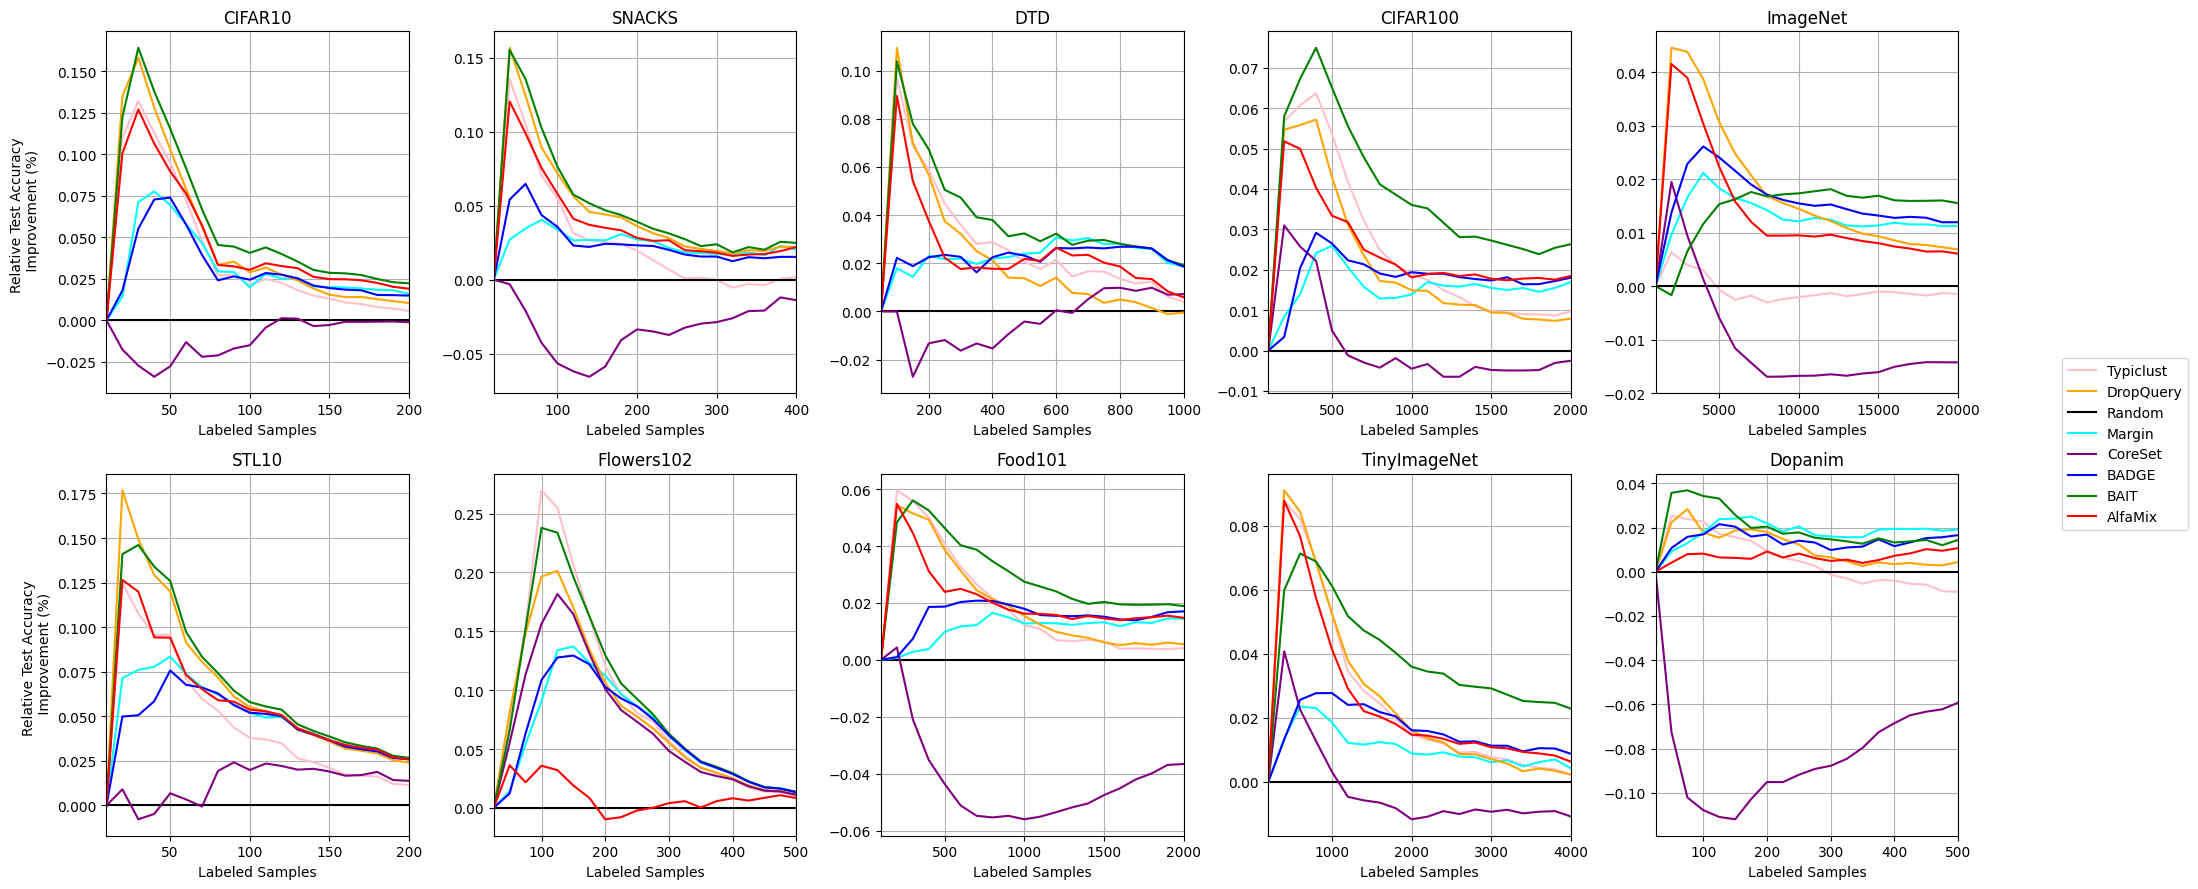

##################################### Final Test-Accuracies (Relative to Random) #####################################


,cifar10,stl10,snacks,flowers102,dtd,food101,cifar100,tiny_imagenet,imagenet,dopanim
random,92.46+/-0.76,96.43+/-0.84,89.81+/-0.89,98.19+/-0.73,75.02+/-0.54,77.65+/-0.31,76.48+/-0.37,72.94+/-0.26,70.37+/-0.14,78.06+/-0.53
typiclust,0.55+/-0.3,1.06+/-0.29,-0.39+/-0.75,0.84+/-0.18,0.22+/-0.8,0.36+/-0.3,0.79+/-0.32,0.19+/-0.39,-0.11+/-0.18,-0.81+/-0.39
margin,1.65+/-0.2,2.5+/-0.1,1.52+/-0.38,1.11+/-0.11,1.61+/-0.77,1.49+/-0.46,1.65+/-0.4,0.47+/-0.32,1.18+/-0.12,2.04+/-0.65
dropquery,1.06+/-0.33,2.26+/-0.09,1.92+/-0.6,0.98+/-0.14,-0.18+/-0.42,0.46+/-0.33,0.79+/-0.26,0.16+/-0.2,0.67+/-0.23,0.37+/-0.64
coreset,0.12+/-0.5,1.39+/-0.32,-1.26+/-0.79,0.9+/-0.11,0.46+/-0.59,-3.64+/-0.64,-0.31+/-0.55,-0.9+/-0.23,-1.31+/-0.2,-5.84+/-0.84
bait,2.22+/-0.18,2.54+/-0.08,2.04+/-0.38,1.11+/-0.1,1.75+/-0.51,1.78+/-0.26,2.54+/-0.34,2.21+/-0.37,1.55+/-0.13,1.63+/-0.31
badge,1.45+/-0.27,2.48+/-0.1,1.39+/-0.61,1.1+/-0.08,1.63+/-0.51,1.61+/-0.43,1.74+/-0.27,0.94+/-0.25,1.26+/-0.16,1.47+/-0.33
alfamix,1.88+/-0.37,2.46+/-0.07,1.7+/-0.59,0.67+/-0.17,0.34+/-0.72,1.45+/-0.28,1.89+/-0.39,0.62+/-0.32,0.63+/-0.2,1.2+/-0.52


##################################### Test-AUCs (Relative to Random) #####################################


,cifar10,stl10,snacks,flowers102,dtd,food101,cifar100,tiny_imagenet,imagenet,dopanim
random,0.833+/-0.016,0.882+/-0.011,0.827+/-0.01,0.812+/-0.014,0.658+/-0.007,0.675+/-0.005,0.667+/-0.005,0.63+/-0.003,0.619+/-0.002,0.711+/-0.008
typiclust,0.037+/-0.006,0.044+/-0.005,0.024+/-0.008,0.083+/-0.006,0.026+/-0.004,0.018+/-0.005,0.024+/-0.004,0.023+/-0.004,-0.001+/-0.002,0.004+/-0.006
margin,0.031+/-0.011,0.048+/-0.003,0.023+/-0.008,0.058+/-0.008,0.022+/-0.005,0.011+/-0.007,0.015+/-0.004,0.01+/-0.002,0.013+/-0.002,0.018+/-0.003
dropquery,0.045+/-0.006,0.063+/-0.004,0.043+/-0.005,0.073+/-0.004,0.02+/-0.004,0.018+/-0.003,0.02+/-0.002,0.024+/-0.002,0.017+/-0.002,0.01+/-0.004
coreset,-0.01+/-0.017,0.013+/-0.011,-0.031+/-0.016,0.065+/-0.008,-0.003+/-0.005,-0.041+/-0.007,0.001+/-0.005,-0.003+/-0.004,-0.01+/-0.002,-0.08+/-0.011
bait,0.055+/-0.009,0.064+/-0.003,0.047+/-0.006,0.084+/-0.005,0.037+/-0.006,0.029+/-0.005,0.037+/-0.003,0.037+/-0.003,0.014+/-0.001,0.019+/-0.006
badge,0.029+/-0.008,0.044+/-0.006,0.023+/-0.005,0.058+/-0.01,0.022+/-0.008,0.015+/-0.006,0.018+/-0.004,0.016+/-0.002,0.015+/-0.002,0.014+/-0.005
alfamix,0.044+/-0.013,0.054+/-0.015,0.036+/-0.006,0.009+/-0.019,0.023+/-0.006,0.02+/-0.005,0.024+/-0.002,0.023+/-0.004,0.013+/-0.002,0.007+/-0.005


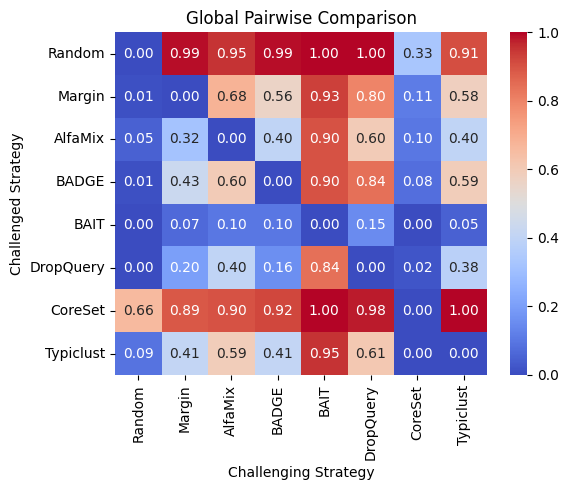

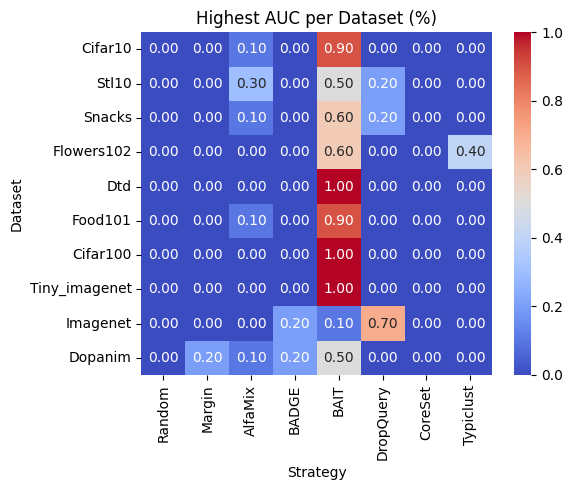

In [12]:
strategies = ['random', 'margin', 'alfamix', 'badge', 'bait', 'dropquery', 'coreset', 'typiclust']
Labels = [query_strategies[strat]['n'] for strat in strategies]
dsets = datasets

final_acc_rel, auc_values_rel = plot_learning_curves(all_acc_curves_strategies, strats=strategies, dsets=dsets, datasets=datasets, query_strategies=query_strategies, nrows=2, ncols=5, figsize=(20, 9))

print('##################################### Final Test-Accuracies (Relative to Random) #####################################')
df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

print('##################################### Test-AUCs (Relative to Random) #####################################')
df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

plot_global_pairwise_comparison(all_acc_curves_strategies, dsets, strategies, Labels=Labels)
plot_global_comparison(all_acc_curves_strategies, dsets, strategies, Labels=Labels)

## Experiment 2 - Oracle Baselines

The second experiment investigates different variants of the oracle strategy and additionally tests them for different number of batches per cycle to investigate.

Oracle_Variants = [Naive, Lazy, Intelligent but Lazy]

Batch_Sizes = [11, 55, 110]

In [9]:
experiment_name = 'experiment_2'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 3 * 3)) # n_dsets * n_seeds * n_query_strategies * num_batches

for run in runs_strategies:
    if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
        key = ('lazy' if 'typiclust' in run.data.params['al.optimal.strategies'] else 'naive') + ('+vary ' if run.data.params['al.optimal.vary_strat_subset_size'] == 'True' else ' ') + 'oracle' + '('+ run.data.params['al.optimal.num_batches'] +')'
        dataset = run.data.params['dataset_name']
        seed = run.data.params['random_seed']

        accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
        qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
        pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

        if len(accs) == 21: # Sorts out runs that accidentally did not track all cycles
            # Save Accuracies
            if dataset not in all_acc_curves_strategies:
                all_acc_curves_strategies[dataset] = {}
            if key not in all_acc_curves_strategies[dataset]:
                all_acc_curves_strategies[dataset][key] = {}
            all_acc_curves_strategies[dataset][key][seed] = accs

            # Save Query Times
            if dataset not in query_times:
                query_times[dataset] = {}
            if key not in query_times[dataset]:
                query_times[dataset][key] = {}
            query_times[dataset][key][seed] = qts

            # Save Pick Choices 
            if dataset not in all_pick_choices:
                all_pick_choices[dataset] = {}
            if key not in all_pick_choices[dataset]:
                all_pick_choices[dataset][key] = {}
            all_pick_choices[dataset][key][seed] = pick_choices
        else:
            print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_2 #####################################
Found 180 experiments for experiment_2 with expected 180 experiments.


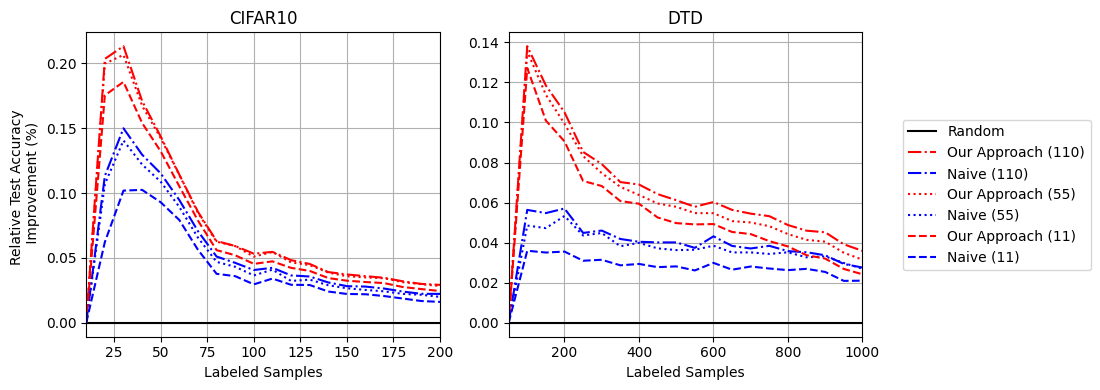

##################################### Final Test-Accuracies (Relative to Random) #####################################


,cifar10,dtd
random,92.46+/-0.76,75.02+/-0.54
lazy+vary oracle(110),2.79+/-0.17,3.39+/-0.56
naive oracle(110),2.17+/-0.19,2.63+/-0.48
lazy+vary oracle(55),2.8+/-0.19,3.11+/-0.55
naive oracle(55),1.97+/-0.25,2.53+/-0.37
lazy+vary oracle(11),2.41+/-0.13,2.12+/-0.5
naive oracle(11),1.62+/-0.3,1.88+/-0.28


##################################### Test-AUCs (Relative to Random) #####################################


,cifar10,dtd
random,0.833+/-0.016,0.658+/-0.007
lazy+vary oracle(110),0.072+/-0.007,0.063+/-0.004
naive oracle(110),0.054+/-0.007,0.038+/-0.005
lazy+vary oracle(55),0.071+/-0.007,0.059+/-0.003
naive oracle(55),0.05+/-0.008,0.036+/-0.003
lazy+vary oracle(11),0.064+/-0.007,0.052+/-0.004
naive oracle(11),0.04+/-0.009,0.027+/-0.004


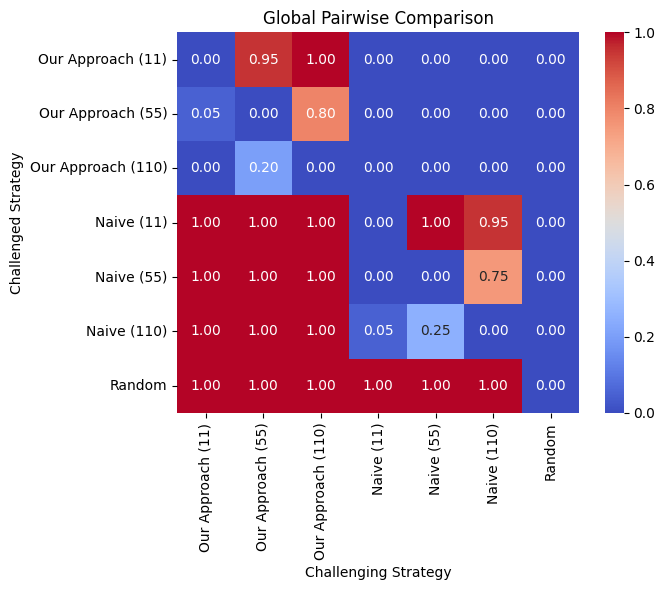

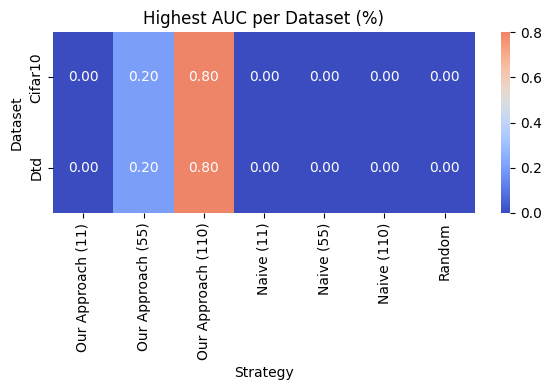

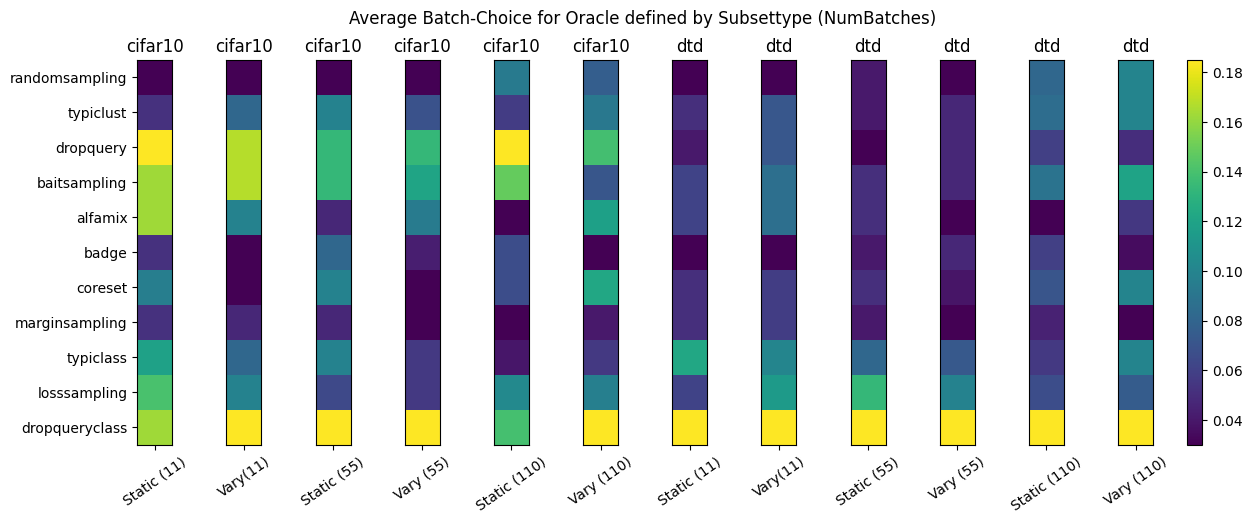

In [13]:
strategies = ['lazy+vary oracle(11)','lazy+vary oracle(55)','lazy+vary oracle(110)','naive oracle(11)','naive oracle(55)','naive oracle(110)','random']
Labels = ['Our Approach (11)', 'Our Approach (55)', 'Our Approach (110)', 'Naive (11)', 'Naive (55)', 'Naive (110)', 'Random']
dsets = ['cifar10', 'dtd']

final_acc_rel, auc_values_rel = plot_learning_curves(all_acc_curves_strategies, strats=strategies, dsets=dsets, datasets=datasets, query_strategies=query_strategies, nrows=1, ncols=2, figsize=(9, 4))

print('##################################### Final Test-Accuracies (Relative to Random) #####################################')
df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

print('##################################### Test-AUCs (Relative to Random) #####################################')
df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

plot_global_pairwise_comparison(all_acc_curves_strategies, dsets, strategies, figsize=(7,6), Labels=Labels)

plot_global_comparison(all_acc_curves_strategies, dsets, strategies, figsize=(6,4), Labels=Labels)

fig_strats = ['lazy oracle(11)', 'lazy+vary oracle(11)', 'lazy oracle(55)', 'lazy+vary oracle(55)', 'lazy oracle(110)', 'lazy+vary oracle(110)']
fig_labels = ['Static (11)', 'Vary(11)', 'Static (55)', 'Vary (55)', 'Static (110)', 'Vary (110)']
plot_average_pick_choices(all_pick_choices, fig_strats, dsets, sampling_strategies, fig_labels)

## Experiment 3 - How does the query size impact the oracle?

This experiment demonstrates the change in performance when increasing the acq_size while keeping the total number of acquisitions over the experiment constant. 

We only use the strategy lazy+vary oracle(110) as it is the strongest performer.

Num_Acqs = [10, 20, 40]

Datasets = [CIFAR10, STL10]

In [60]:
experiment_name = 'experiment_3'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 3 * 10 * 4)) # n_dsets * n_seeds * n_acq_sizes

for run in runs_strategies:
    if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
        key = f'Lazy+Vary Oracle (acq_size = '+run.data.params['al.acq_size']+')'
        dataset = run.data.params['dataset_name']
        seed = run.data.params['random_seed']

        accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
        qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
        pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

        if str(len(accs)-1) == run.data.params['al.num_acq']: # Sorts out runs that accidentally did not track all cycles
            # Save Accuracies
            if dataset not in all_acc_curves_strategies:
                all_acc_curves_strategies[dataset] = {}
            if key not in all_acc_curves_strategies[dataset]:
                all_acc_curves_strategies[dataset][key] = {}
            all_acc_curves_strategies[dataset][key][seed] = accs

            # Save Query Times
            if dataset not in query_times:
                query_times[dataset] = {}
            if key not in query_times[dataset]:
                query_times[dataset][key] = {}
            query_times[dataset][key][seed] = qts

            # Save Pick Choices 
            if dataset not in all_pick_choices:
                all_pick_choices[dataset] = {}
            if key not in all_pick_choices[dataset]:
                all_pick_choices[dataset][key] = {}
            all_pick_choices[dataset][key][seed] = pick_choices
        else:
            print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_3 #####################################
Found 90 experiments for experiment_3 with expected 120 experiments.
Issue with Lazy+Vary Oracle (acq_size = 5) cifar10 Seed_7


In [ ]:
strategies = ['Lazy+Vary Oracle (acq_size = 5)', 'Lazy+Vary Oracle (acq_size = 10)', 'Lazy+Vary Oracle (acq_size = 20)', 'Lazy+Vary Oracle (acq_size = 40)']
Labels = [query_strategies[strat]['n'] for strat in strategies]
dsets = ['cifar10', 'stl10']

final_acc_rel, auc_values_rel = plot_learning_curves(all_acc_curves_strategies, strats=strategies, dsets=dsets, datasets=datasets, query_strategies=query_strategies, nrows=1, ncols=2, figsize=(9, 4), only_tables=True)

print('##################################### Final Test-Accuracies (Relative to Random) #####################################')
df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

print('##################################### Test-AUCs (Relative to Random) #####################################')
df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

##################################### Final Test-Accuracies (Relative to Random) #####################################


,cifar10,stl10
random,92.46+/-0.76,96.43+/-0.84
Lazy+Vary Oracle (acq_size = 20),2.65+/-0.21,2.59+/-0.07
Lazy+Vary Oracle (acq_size = 5),3.02+/-0.14,2.62+/-0.09
Lazy+Vary Oracle (acq_size = 10),2.79+/-0.17,2.62+/-0.09


##################################### Test-AUCs (Relative to Random) #####################################


,cifar10,stl10
random,0.833+/-0.016,0.882+/-0.011
Lazy+Vary Oracle (acq_size = 20),0.05+/-0.009,0.05+/-0.004
Lazy+Vary Oracle (acq_size = 5),0.083+/-0.004,0.08+/-0.002
Lazy+Vary Oracle (acq_size = 10),0.072+/-0.006,0.07+/-0.002


## Experiment 4 - How does the performance estimation impact the oracle?

In this experiment, we investigate the influence of the performance metric used for evaluating the different batches.

Perf_Est = [Cross Entropy, 0/1 Loss, Brier Score]

In [66]:
experiment_name = 'experiment_4'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 3)) # n_dsets * n_seeds * n_loss_fn

for run in runs_strategies:
    if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
        key = f'Lazy+Vary Oracle (perf_est = '+run.data.params['al.optimal.loss']+')'
        dataset = run.data.params['dataset_name']
        seed = run.data.params['random_seed']

        accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
        qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
        pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

        if str(len(accs)-1) == run.data.params['al.num_acq']: # Sorts out runs that accidentally did not track all cycles
            # Save Accuracies
            if dataset not in all_acc_curves_strategies:
                all_acc_curves_strategies[dataset] = {}
            if key not in all_acc_curves_strategies[dataset]:
                all_acc_curves_strategies[dataset][key] = {}
            all_acc_curves_strategies[dataset][key][seed] = accs

            # Save Query Times
            if dataset not in query_times:
                query_times[dataset] = {}
            if key not in query_times[dataset]:
                query_times[dataset][key] = {}
            query_times[dataset][key][seed] = qts

            # Save Pick Choices 
            if dataset not in all_pick_choices:
                all_pick_choices[dataset] = {}
            if key not in all_pick_choices[dataset]:
                all_pick_choices[dataset][key] = {}
            all_pick_choices[dataset][key][seed] = pick_choices
        else:
            print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_4 #####################################
Found 60 experiments for experiment_4 with expected 60 experiments.


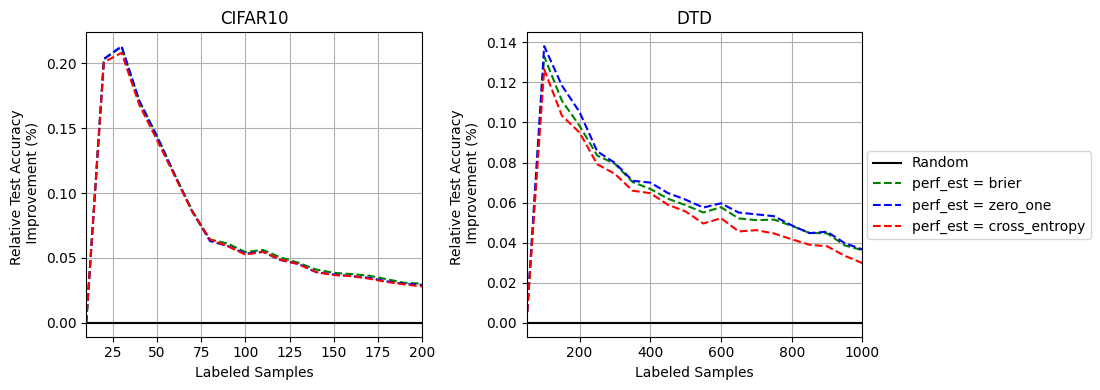

##################################### Final Test-Accuracies (Relative to Random) #####################################


,cifar10,dtd
random,92.46+/-0.76,75.02+/-0.54
Lazy+Vary Oracle (perf_est = brier),2.98+/-0.16,3.36+/-0.48
Lazy+Vary Oracle (perf_est = zero_one),2.79+/-0.17,3.4+/-0.6
Lazy+Vary Oracle (perf_est = cross_entropy),2.81+/-0.12,2.76+/-0.57


##################################### Test-AUCs (Relative to Random) #####################################


,cifar10,dtd
random,0.833+/-0.016,0.658+/-0.007
Lazy+Vary Oracle (perf_est = brier),0.073+/-0.007,0.061+/-0.003
Lazy+Vary Oracle (perf_est = zero_one),0.072+/-0.007,0.063+/-0.005
Lazy+Vary Oracle (perf_est = cross_entropy),0.072+/-0.006,0.056+/-0.004


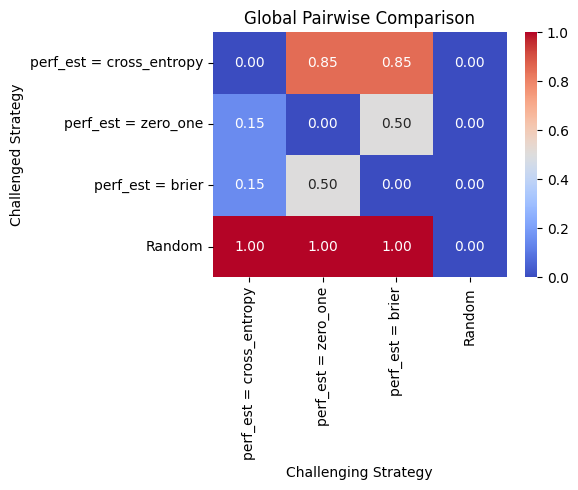

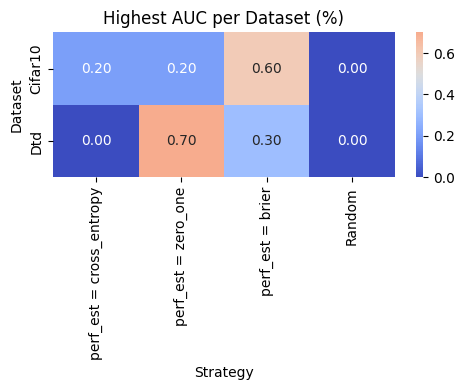

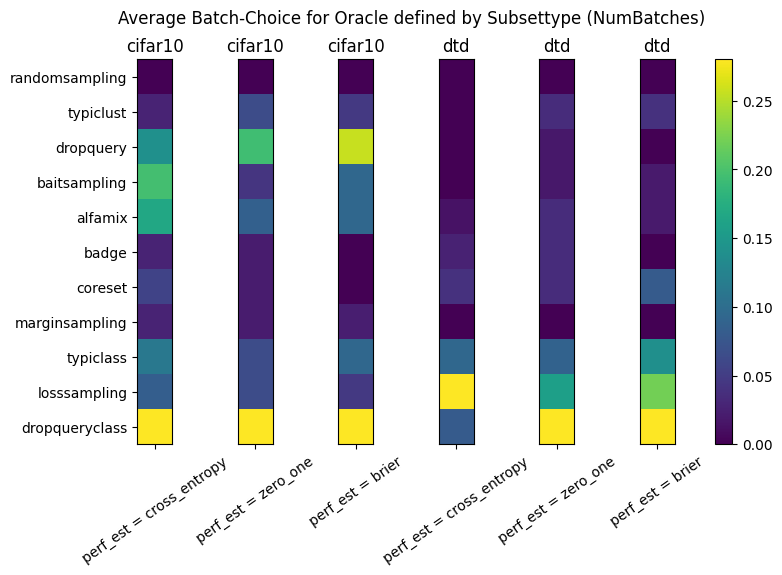

In [69]:
strategies = [qs for qs in query_strategies if 'perf_est' in qs] + ['random']
Labels = [query_strategies[strat]['n'] for strat in strategies]
dsets = ['cifar10', 'dtd']

final_acc_rel, auc_values_rel = plot_learning_curves(strats=strategies, dsets=dsets, datasets=datasets, query_strategies=query_strategies, nrows=1, ncols=2, figsize=(9, 4))

print('##################################### Final Test-Accuracies (Relative to Random) #####################################')
df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

print('##################################### Test-AUCs (Relative to Random) #####################################')
df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

plot_global_pairwise_comparison(all_acc_curves_strategies, dsets, strategies, figsize=(6,5), Labels=Labels)

plot_global_comparison(all_acc_curves_strategies, dsets, strategies, figsize=(5,4), Labels=Labels)

fig_strats = strategies
fig_strats.remove('random')
fig_labels = [query_strategies[strat]['n'] for strat in fig_strats]
plot_average_pick_choices(all_pick_choices, fig_strats, dsets, sampling_strategies, fig_labels, figsize=(8, 5))

## Experiment 5 - How does the retraining process impact the oracle?

This experiment investigates wether using bayesian updates instead of retraining the model from scratch can serve as a good performance estimator, making the oracle more efficient.

In [70]:
experiment_name = 'experiment_5'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 10 * 3)) # n_dsets * n_seeds * n_gammas * n_loss_fn

for run in runs_strategies:
    if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
        loss_fn = run.data.params['al.optimal.loss']
        update_gamma = run.data.params['al.optimal.update_gamma']
        key = f'lazy+vary oracle(110) ' + loss_fn + ' ' + update_gamma
        dataset = run.data.params['dataset_name']
        seed = run.data.params['random_seed']

        accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
        qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
        pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

        if str(len(accs)-1) == run.data.params['al.num_acq']: # Sorts out runs that accidentally did not track all cycles
            # Save Accuracies
            if dataset not in all_acc_curves_strategies:
                all_acc_curves_strategies[dataset] = {}
            if key not in all_acc_curves_strategies[dataset]:
                all_acc_curves_strategies[dataset][key] = {}
            all_acc_curves_strategies[dataset][key][seed] = accs

            # Save Query Times
            if dataset not in query_times:
                query_times[dataset] = {}
            if key not in query_times[dataset]:
                query_times[dataset][key] = {}
            query_times[dataset][key][seed] = qts

            # Save Pick Choices 
            if dataset not in all_pick_choices:
                all_pick_choices[dataset] = {}
            if key not in all_pick_choices[dataset]:
                all_pick_choices[dataset][key] = {}
            all_pick_choices[dataset][key][seed] = pick_choices
        else:
            print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_5 #####################################
Found 600 experiments for experiment_5 with expected 600 experiments.


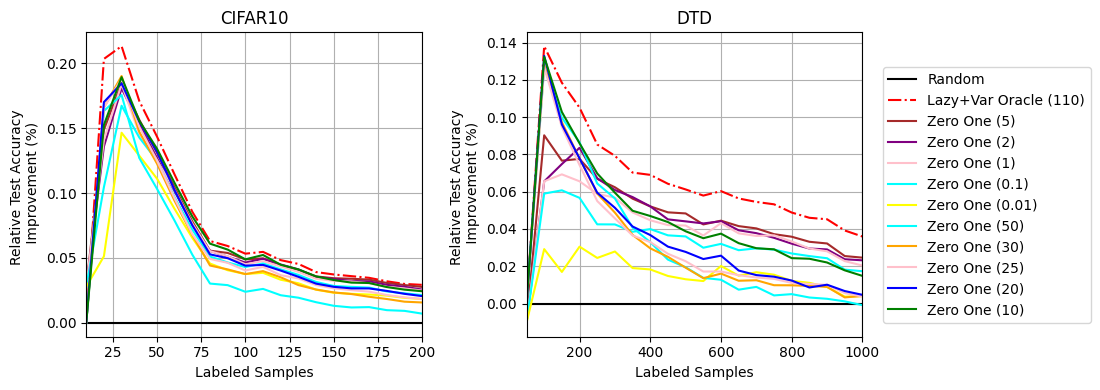

##################################### Final Test-Accuracies (Relative to Random) #####################################


,cifar10,dtd
random,92.46+/-0.76,75.02+/-0.54
lazy+vary oracle(110),2.79+/-0.17,3.39+/-0.56
lazy+vary oracle(110) zero_one 5,2.71+/-0.15,2.19+/-0.38
lazy+vary oracle(110) zero_one 2,2.58+/-0.19,2.09+/-0.49
lazy+vary oracle(110) zero_one 1,2.48+/-0.18,1.8+/-0.43
lazy+vary oracle(110) zero_one 0.1,2.09+/-0.3,1.43+/-0.62
lazy+vary oracle(110) zero_one 0.01,1.9+/-0.32,0.06+/-0.38
lazy+vary oracle(110) zero_one 50,0.71+/-0.42,-0.36+/-0.57
lazy+vary oracle(110) zero_one 30,1.6+/-0.25,0.27+/-0.68
lazy+vary oracle(110) zero_one 25,1.78+/-0.17,0.26+/-0.46


##################################### Test-AUCs (Relative to Random) #####################################


,cifar10,dtd
random,0.833+/-0.016,0.658+/-0.007
lazy+vary oracle(110),0.072+/-0.007,0.063+/-0.004
lazy+vary oracle(110) zero_one 5,0.066+/-0.004,0.045+/-0.005
lazy+vary oracle(110) zero_one 2,0.063+/-0.004,0.043+/-0.007
lazy+vary oracle(110) zero_one 1,0.063+/-0.004,0.039+/-0.004
lazy+vary oracle(110) zero_one 0.1,0.057+/-0.006,0.032+/-0.006
lazy+vary oracle(110) zero_one 0.01,0.048+/-0.007,0.014+/-0.009
lazy+vary oracle(110) zero_one 50,0.045+/-0.009,0.029+/-0.004
lazy+vary oracle(110) zero_one 30,0.056+/-0.007,0.03+/-0.008
lazy+vary oracle(110) zero_one 25,0.058+/-0.007,0.03+/-0.004


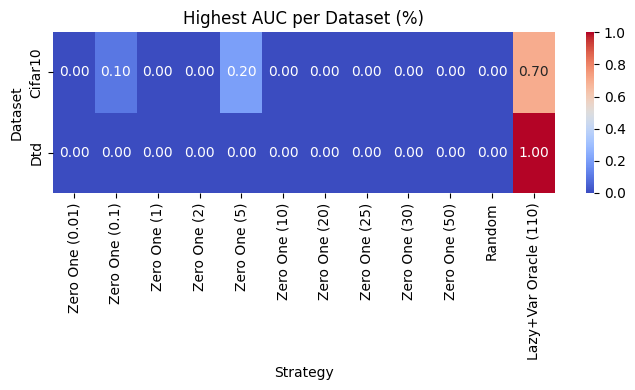

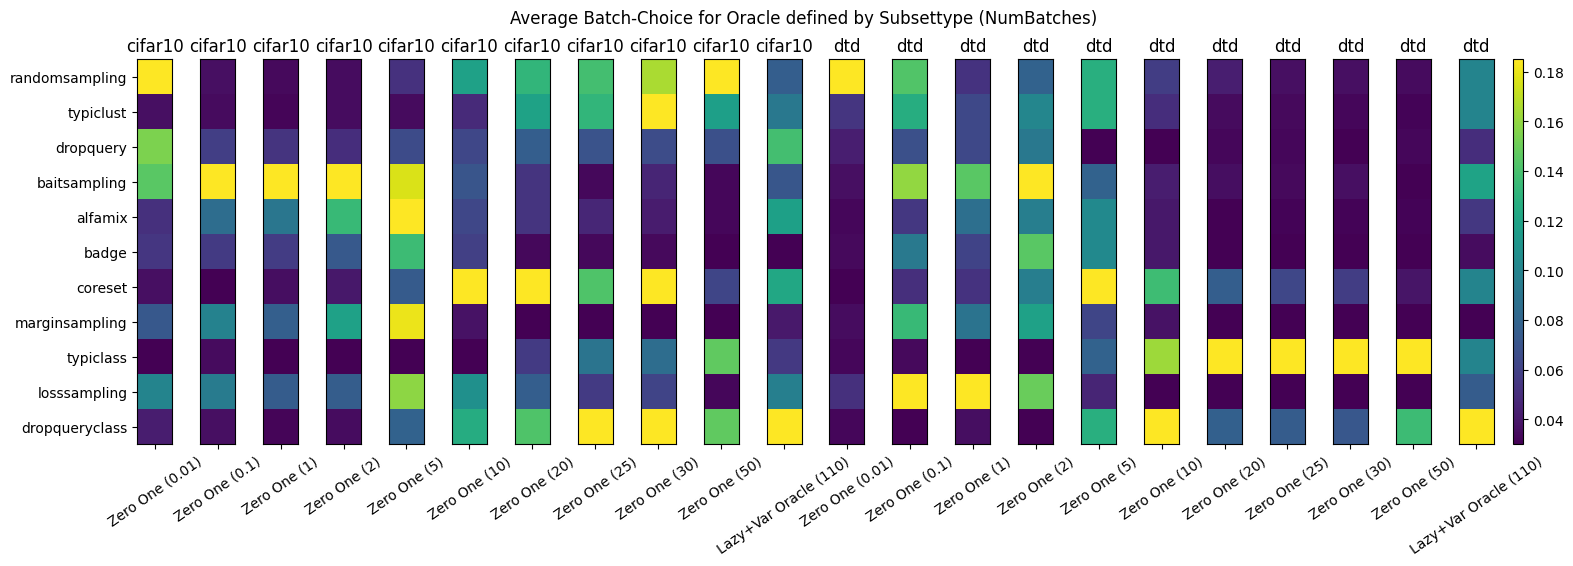

In [ ]:
strategies = [qs for qs in query_strategies if 'zero_one ' in qs] + ['random', 'lazy+vary oracle(110)']
Labels = [query_strategies[strat]['n'] for strat in strategies]
dsets = ['cifar10', 'dtd']

final_acc_rel, auc_values_rel = plot_learning_curves(all_acc_curves_strategies, strats=strategies, dsets=dsets, datasets=datasets, query_strategies=query_strategies, nrows=1, ncols=2, figsize=(9, 4))

print('##################################### Final Test-Accuracies (Relative to Random) #####################################')
df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

print('##################################### Test-AUCs (Relative to Random) #####################################')
df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

plot_global_comparison(all_acc_curves_strategies, dsets, strategies, figsize=(7,4), Labels=Labels)

fig_strats = strategies
fig_strats.remove('random')
fig_labels = [query_strategies[strat]['n'] for strat in fig_strats]
plot_average_pick_choices(all_pick_choices, fig_strats, dsets, sampling_strategies, fig_labels, figsize=(18, 5))

In [78]:
qts = {}

for dset in ['cifar10', 'dtd']:
    qts[dset] = {}
    for strat in ['lazy+vary oracle(110)', 'lazy+vary oracle(110) zero_one 10']:
        qts[dset][strat] = {}
        times = np.mean(list(query_times[dset][strat].values()), axis=0).round(2)
        for cycle in range(20):
            qts[dset][strat]['Cycle '+str(cycle)] = times[cycle]

flat_dict = {}
for group, subdict in qts.items():
    for sub, rows in subdict.items():
        for row, value in rows.items():
            flat_dict.setdefault(row, {})[(group, sub)] = value

# Step 2: Create the DataFrame
df = pd.DataFrame.from_dict(flat_dict, orient='index')

# Step 3: Sort columns if needed
df = df.sort_index(axis=1)

df

cifar10                                    \
         lazy+vary oracle(110) lazy+vary oracle(110) zero_one 10   
Cycle 0                   0.00                              0.00   
Cycle 1                  61.55                             52.85   
Cycle 2                  62.81                             53.29   
Cycle 3                  58.69                             51.50   
Cycle 4                  59.26                             50.18   
Cycle 5                  58.99                             54.68   
Cycle 6                  61.46                             53.00   
Cycle 7                  58.03                             52.06   
Cycle 8                  59.27                             48.90   
Cycle 9                  61.47                             48.92   
Cycle 10                 59.24                             50.53   
Cycle 11                 61.53                             51.48   
Cycle 12                 70.55                             52.01   
Cycle 13                 71.66                             49.49   
Cycle 14                 70.79                             51.11   
Cycle 15                 71.53                             50.24   
Cycle 16                 69.60                             51.95   
Cycle 17                 70.94                             52.83   
Cycle 18                 71.09                             50.87   
Cycle 19                 81.56                             49.58   

                           dtd                                    
         lazy+vary oracle(110) lazy+vary oracle(110) zero_one 10  
Cycle 0                   0.00                              0.00  
Cycle 1                  65.43                             58.80  
Cycle 2                  67.35                             54.32  
Cycle 3                  73.81                             57.49  
Cycle 4                  75.64                             50.74  
Cycle 5                  81.87                             47.63  
Cycle 6                  94.67                             46.92  
Cycle 7                 101.48                             44.84  
Cycle 8                 112.94                             47.11  
Cycle 9                 113.36                             45.70  
Cycle 10                120.98                             47.29  
Cycle 11                132.28                             43.27  
Cycle 12                142.57                             42.51  
Cycle 13                138.87                             45.17  
Cycle 14                145.14                             44.53  
Cycle 15                151.99                             41.36  
Cycle 16                162.04                             50.65  
Cycle 17                172.24                             39.14  
Cycle 18                168.88                             42.53  
Cycle 19                178.27                             39.89

# Experiment 6 - Final Oracle Model on all Image-Datasets

The final oracle-model is build as follows:

Number of Batches: 110

Selection Strategies: All except Margin and BADGE

Performance Estimation: Brier-Score

In [79]:
experiment_name = 'experiment_7'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 9 * 10)) # n_dsets * n_seeds

for run in runs_strategies:
    if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
        key = 'Oracle'
        dataset = run.data.params['dataset_name']
        backbone = run.data.params['backbone']
        seed = run.data.params['random_seed']
        if backbone == 'dinov2':
            accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
            qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
            pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

            if str(len(accs)-1) == run.data.params['al.num_acq']: # Sorts out runs that accidentally did not track all cycles
                # Save Accuracies
                if dataset not in all_acc_curves_strategies:
                    all_acc_curves_strategies[dataset] = {}
                if key not in all_acc_curves_strategies[dataset]:
                    all_acc_curves_strategies[dataset][key] = {}
                all_acc_curves_strategies[dataset][key][seed] = accs

                # Save Query Times
                if dataset not in query_times:
                    query_times[dataset] = {}
                if key not in query_times[dataset]:
                    query_times[dataset][key] = {}
                query_times[dataset][key][seed] = qts

                # Save Pick Choices 
                if dataset not in all_pick_choices:
                    all_pick_choices[dataset] = {}
                if key not in all_pick_choices[dataset]:
                    all_pick_choices[dataset][key] = {}
                all_pick_choices[dataset][key][seed] = pick_choices
            else:
                print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_7 #####################################
Found 207 experiments for experiment_7 with expected 90 experiments.


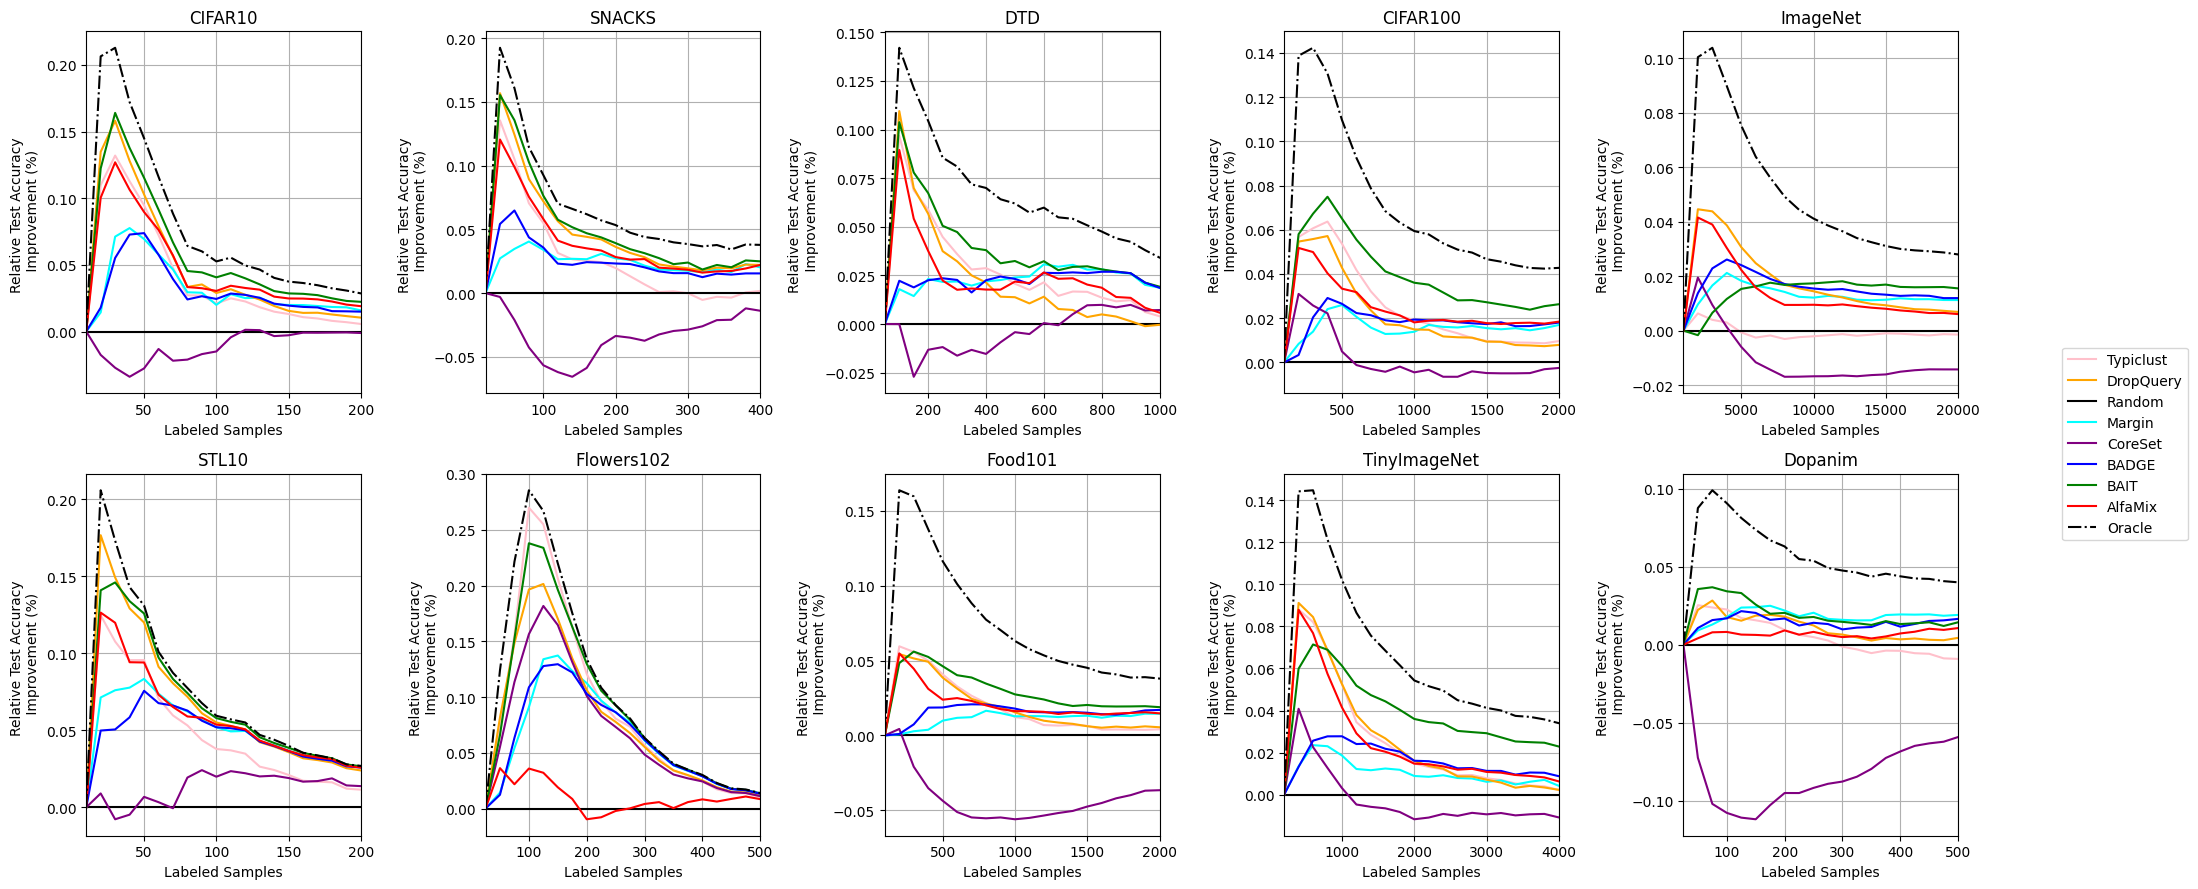

##################################### Final Test-Accuracies (Relative to Random) #####################################


,cifar10,stl10,snacks,flowers102,dtd,food101,cifar100,tiny_imagenet,imagenet,dopanim
random,92.46+/-0.76,96.43+/-0.84,89.81+/-0.89,98.19+/-0.73,75.02+/-0.54,77.65+/-0.31,76.48+/-0.37,72.94+/-0.26,70.37+/-0.14,78.06+/-0.53
typiclust,0.55+/-0.3,1.06+/-0.29,-0.39+/-0.75,0.84+/-0.18,0.22+/-0.8,0.36+/-0.3,0.79+/-0.32,0.19+/-0.39,-0.11+/-0.18,-0.81+/-0.39
margin,1.65+/-0.2,2.5+/-0.1,1.52+/-0.38,1.11+/-0.11,1.61+/-0.77,1.49+/-0.46,1.65+/-0.4,0.47+/-0.32,1.18+/-0.12,2.04+/-0.65
dropquery,1.06+/-0.33,2.26+/-0.09,1.92+/-0.6,0.98+/-0.14,-0.18+/-0.42,0.46+/-0.33,0.79+/-0.26,0.16+/-0.2,0.67+/-0.23,0.37+/-0.64
coreset,0.12+/-0.5,1.39+/-0.32,-1.26+/-0.79,0.9+/-0.11,0.46+/-0.59,-3.64+/-0.64,-0.31+/-0.55,-0.9+/-0.23,-1.31+/-0.2,-5.84+/-0.84
bait,2.22+/-0.18,2.54+/-0.08,2.04+/-0.38,1.11+/-0.1,1.75+/-0.51,1.78+/-0.26,2.54+/-0.34,2.21+/-0.37,1.55+/-0.13,1.63+/-0.31
badge,1.45+/-0.27,2.48+/-0.1,1.39+/-0.61,1.1+/-0.08,1.63+/-0.51,1.61+/-0.43,1.74+/-0.27,0.94+/-0.25,1.26+/-0.16,1.47+/-0.33
alfamix,1.88+/-0.37,2.46+/-0.07,1.7+/-0.59,0.67+/-0.17,0.34+/-0.72,1.45+/-0.28,1.89+/-0.39,0.62+/-0.32,0.63+/-0.2,1.2+/-0.52
Oracle,2.79+/-0.2,2.56+/-0.09,3.22+/-0.39,1.14+/-0.1,3.21+/-0.46,3.64+/-0.23,4.23+/-0.33,3.42+/-0.31,2.79+/-0.12,3.95+/-0.31


##################################### Test-AUCs (Relative to Random) #####################################


,cifar10,stl10,snacks,flowers102,dtd,food101,cifar100,tiny_imagenet,imagenet,dopanim
random,0.833+/-0.016,0.882+/-0.011,0.827+/-0.01,0.812+/-0.014,0.658+/-0.007,0.675+/-0.005,0.667+/-0.005,0.63+/-0.003,0.619+/-0.002,0.711+/-0.008
typiclust,0.037+/-0.006,0.044+/-0.005,0.024+/-0.008,0.083+/-0.006,0.026+/-0.004,0.018+/-0.005,0.024+/-0.004,0.023+/-0.004,-0.001+/-0.002,0.004+/-0.006
margin,0.031+/-0.011,0.048+/-0.003,0.023+/-0.008,0.058+/-0.008,0.022+/-0.005,0.011+/-0.007,0.015+/-0.004,0.01+/-0.002,0.013+/-0.002,0.018+/-0.003
dropquery,0.045+/-0.006,0.063+/-0.004,0.043+/-0.005,0.073+/-0.004,0.02+/-0.004,0.018+/-0.003,0.02+/-0.002,0.024+/-0.002,0.017+/-0.002,0.01+/-0.004
coreset,-0.01+/-0.017,0.013+/-0.011,-0.031+/-0.016,0.065+/-0.008,-0.003+/-0.005,-0.041+/-0.007,0.001+/-0.005,-0.003+/-0.004,-0.01+/-0.002,-0.08+/-0.011
bait,0.055+/-0.009,0.064+/-0.003,0.047+/-0.006,0.084+/-0.005,0.037+/-0.006,0.029+/-0.005,0.037+/-0.003,0.037+/-0.003,0.014+/-0.001,0.019+/-0.006
badge,0.029+/-0.008,0.044+/-0.006,0.023+/-0.005,0.058+/-0.01,0.022+/-0.008,0.015+/-0.006,0.018+/-0.004,0.016+/-0.002,0.015+/-0.002,0.014+/-0.005
alfamix,0.044+/-0.013,0.054+/-0.015,0.036+/-0.006,0.009+/-0.019,0.023+/-0.006,0.02+/-0.005,0.024+/-0.002,0.023+/-0.004,0.013+/-0.002,0.007+/-0.005
Oracle,0.073+/-0.007,0.07+/-0.003,0.062+/-0.005,0.096+/-0.005,0.063+/-0.006,0.07+/-0.003,0.067+/-0.003,0.062+/-0.002,0.046+/-0.001,0.055+/-0.003


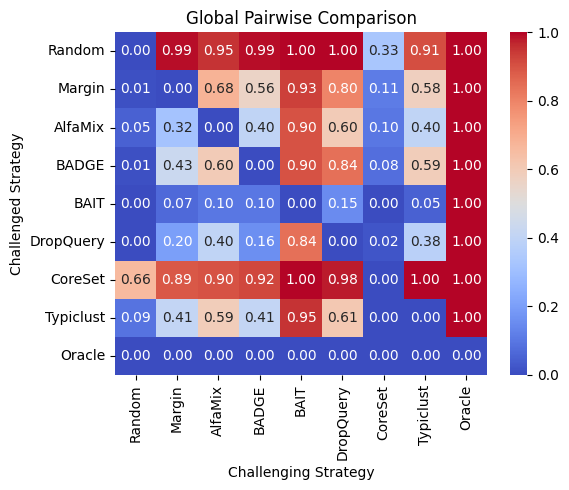

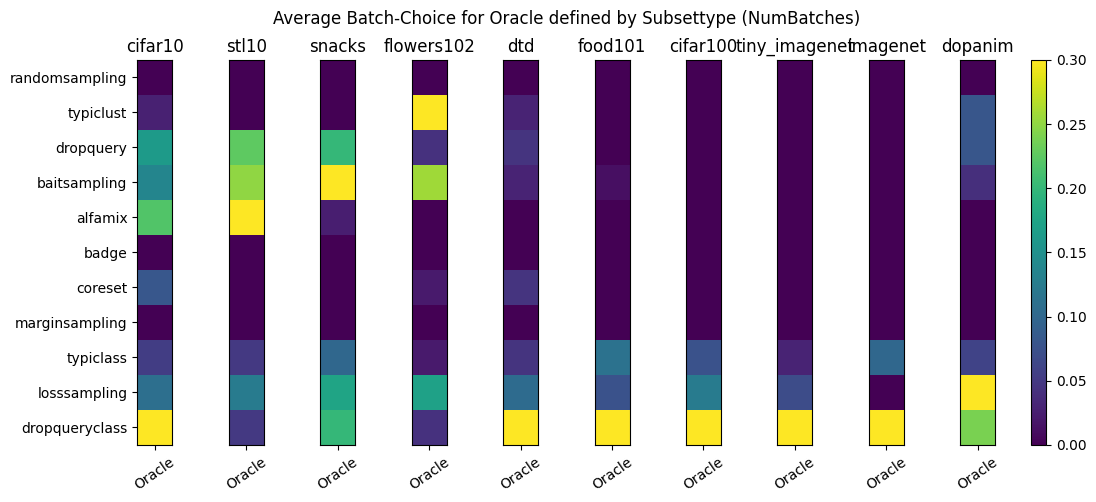

In [ ]:
strategies = ['random', 'margin', 'alfamix', 'badge', 'bait', 'dropquery', 'coreset', 'typiclust', 'Oracle']
Labels = [query_strategies[strat]['n'] for strat in strategies]
dsets = datasets

final_acc_rel, auc_values_rel = plot_learning_curves(all_acc_curves_strategies, strats=strategies, dsets=dsets, datasets=datasets, query_strategies=query_strategies, nrows=2, ncols=5, figsize=(20, 9))

print('##################################### Final Test-Accuracies (Relative to Random) #####################################')
df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

print('##################################### Test-AUCs (Relative to Random) #####################################')
df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

plot_global_pairwise_comparison(all_acc_curves_strategies, dsets, strategies, figsize=(6,5), Labels=Labels)

fig_strats = ['Oracle']
fig_labels = ['Oracle']
plot_average_pick_choices(all_pick_choices, fig_strats, dsets, sampling_strategies, fig_labels, figsize=(12, 5))

## Experiment 7: Baselines+Oracle with a new Backbone (SwinV2) on all Image Datasets
Accidentally, i also saved this final oracle under the same experiment number (experiment_7). I therefore need to make a case differentiation between the backbones for future evaluations for both backbones!!!

In [88]:
all_acc_curves_strategies_2 = {}
all_pick_choices_2 = {}
query_times_2 = {}

In [89]:
experiment_name = 'experiment_8'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 9 * 10 * 8)) # n_dsets * n_seeds * n_query_strategies

for run in runs_strategies:
    if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
        key = run.data.params['al.strategy']
        dataset = run.data.params['dataset_name']
        seed = run.data.params['random_seed']
        accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
        qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]

        if str(len(accs)-1) == run.data.params['al.num_acq']: # Sorts out runs that accidentally did not track all cycles
            # Save Accuracies
            if dataset not in all_acc_curves_strategies_2:
                all_acc_curves_strategies_2[dataset] = {}
            if key not in all_acc_curves_strategies_2[dataset]:
                all_acc_curves_strategies_2[dataset][key] = {}
            all_acc_curves_strategies_2[dataset][key][seed] = accs

            # Save Query Times
            if dataset not in query_times_2:
                query_times_2[dataset] = {}
            if key not in query_times_2[dataset]:
                query_times_2[dataset][key] = {}
            query_times_2[dataset][key][seed] = qts
        else:
            print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_8 #####################################
Found 824 experiments for experiment_8 with expected 720 experiments.
Issue with typiclust dopanim Seed_8
Issue with typiclust dopanim Seed_6
Issue with coreset dopanim Seed_4
Issue with dropquery dopanim Seed_4


In [90]:
experiment_name = 'experiment_7'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 9 * 10)) # n_dsets * n_seeds

for run in runs_strategies:
    if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
        key = 'Oracle'
        dataset = run.data.params['dataset_name']
        backbone = run.data.params['backbone']
        if backbone == 'swinv2':
            seed = run.data.params['random_seed']
            accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
            qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
            pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

            if str(len(accs)-1) == run.data.params['al.num_acq']: # Sorts out runs that accidentally did not track all cycles
                # Save Accuracies
                if dataset not in all_acc_curves_strategies_2:
                    all_acc_curves_strategies_2[dataset] = {}
                if key not in all_acc_curves_strategies_2[dataset]:
                    all_acc_curves_strategies_2[dataset][key] = {}
                all_acc_curves_strategies_2[dataset][key][seed] = accs

                # Save Query Times
                if dataset not in query_times_2:
                    query_times_2[dataset] = {}
                if key not in query_times_2[dataset]:
                    query_times_2[dataset][key] = {}
                query_times_2[dataset][key][seed] = qts

                # Save Pick Choices 
                if dataset not in all_pick_choices_2:
                    all_pick_choices_2[dataset] = {}
                if key not in all_pick_choices_2[dataset]:
                    all_pick_choices_2[dataset][key] = {}
                all_pick_choices_2[dataset][key][seed] = pick_choices
            else:
                print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_7 #####################################
Found 207 experiments for experiment_7 with expected 90 experiments.


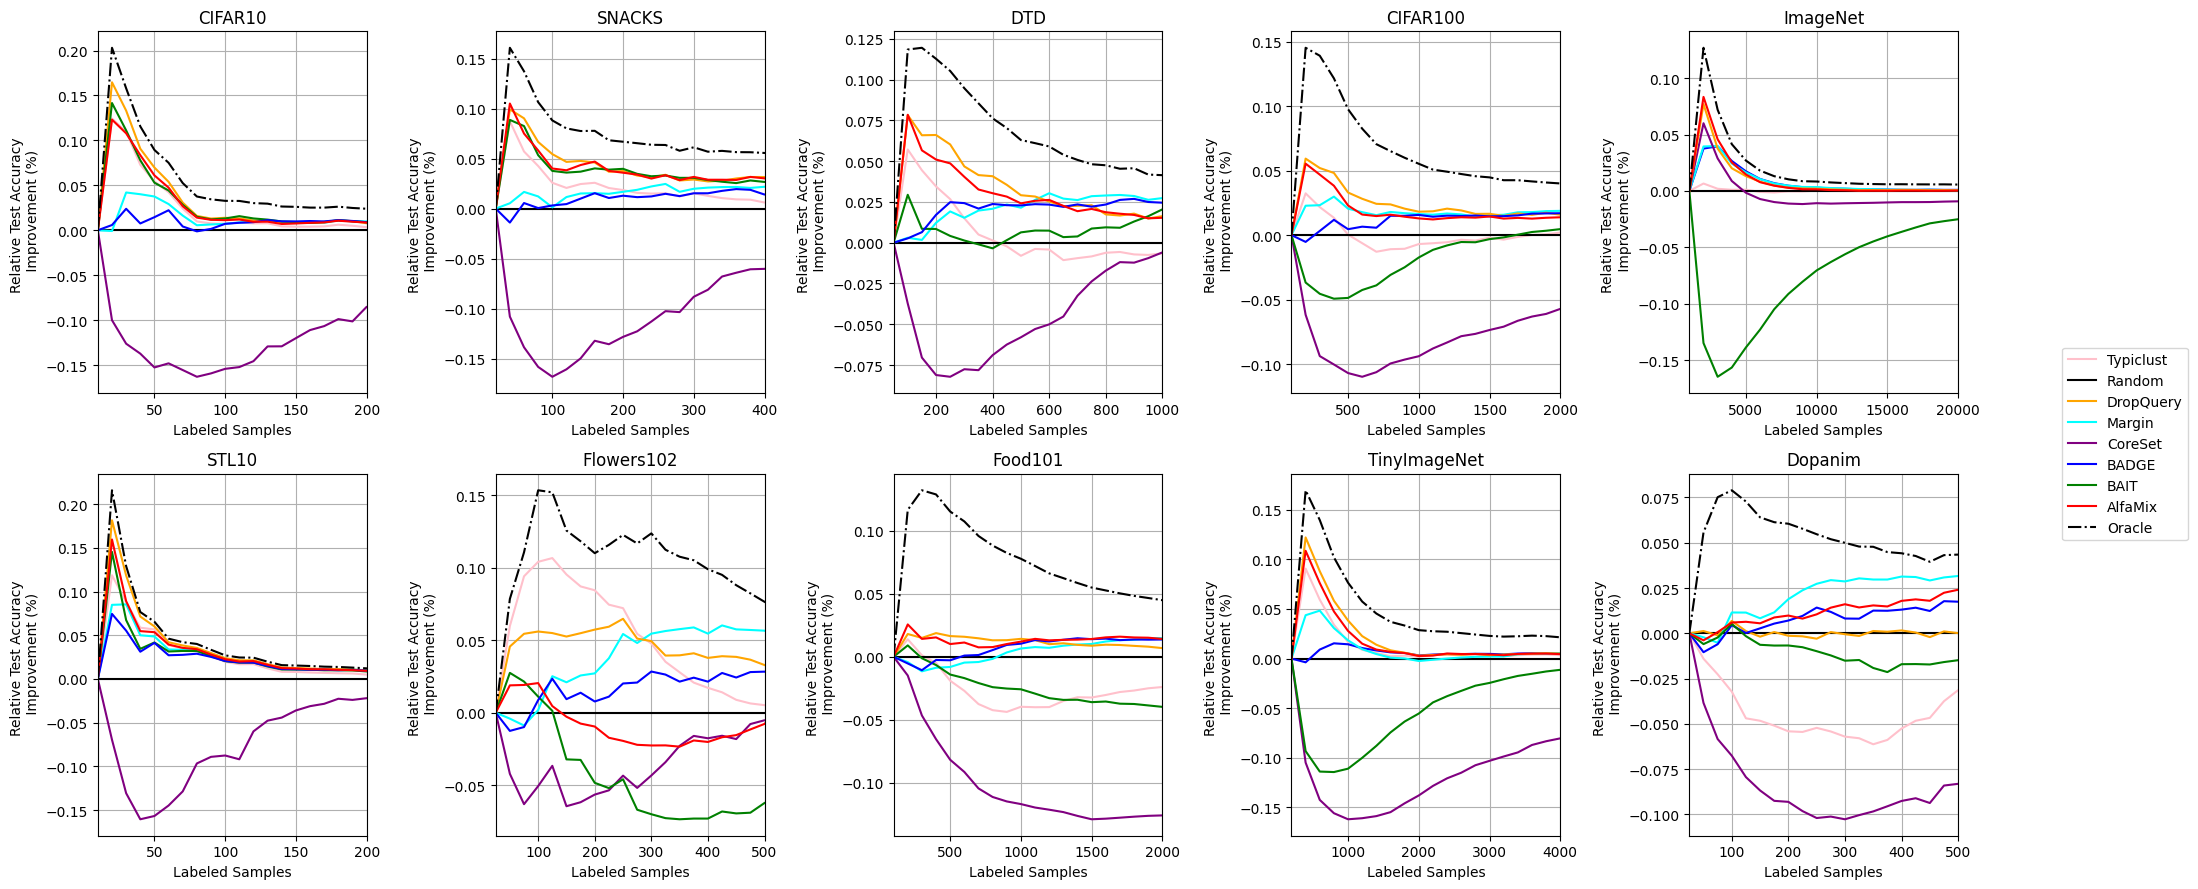

##################################### Final Test-Accuracies (Relative to Random) #####################################


,cifar10,stl10,snacks,flowers102,dtd,food101,cifar100,tiny_imagenet,imagenet,dopanim
random,90.93+/-0.5,97.88+/-0.24,83.4+/-1.0,74.26+/-0.96,67.14+/-0.56,59.51+/-0.39,70.92+/-0.4,79.6+/-0.36,83.47+/-0.06,73.21+/-0.78
typiclust,0.5+/-0.35,0.45+/-0.13,0.75+/-0.85,0.49+/-1.0,-0.63+/-0.3,-2.24+/-0.35,0.23+/-0.22,0.33+/-0.28,0.05+/-0.06,-2.64+/-0.93
margin,1.12+/-0.34,0.94+/-0.1,2.28+/-0.73,5.2+/-0.58,2.32+/-0.57,1.56+/-0.56,1.89+/-0.41,0.55+/-0.2,0.05+/-0.06,3.07+/-0.48
dropquery,0.99+/-0.34,0.9+/-0.06,3.01+/-0.46,3.02+/-0.63,1.6+/-0.58,0.67+/-0.5,1.47+/-0.25,0.44+/-0.25,0.05+/-0.05,-0.08+/-1.13
coreset,-8.36+/-3.5,-2.15+/-2.87,-5.75+/-2.33,-0.6+/-1.22,-0.2+/-0.61,-12.58+/-1.2,-5.37+/-0.68,-7.74+/-1.16,-0.91+/-0.18,-8.07+/-1.39
bait,1.01+/-0.24,0.86+/-0.05,2.74+/-0.76,-5.81+/-1.21,2.19+/-0.47,-4.0+/-0.54,0.48+/-0.7,-0.99+/-0.55,-2.27+/-0.37,-1.43+/-0.8
badge,0.95+/-0.42,0.89+/-0.09,1.71+/-0.71,2.58+/-0.75,2.35+/-0.76,1.51+/-0.4,1.77+/-0.29,0.55+/-0.11,0.08+/-0.06,1.92+/-0.81
alfamix,0.91+/-0.41,0.86+/-0.08,2.74+/-0.75,0.16+/-1.92,1.32+/-0.49,1.47+/-0.42,1.26+/-0.45,0.48+/-0.33,0.03+/-0.08,2.44+/-0.79
Oracle,2.47+/-0.12,1.16+/-0.08,5.48+/-0.53,7.13+/-0.39,3.62+/-0.58,4.38+/-0.4,3.85+/-0.18,2.07+/-0.16,0.56+/-0.02,4.34+/-0.48


##################################### Test-AUCs (Relative to Random) #####################################


,cifar10,stl10,snacks,flowers102,dtd,food101,cifar100,tiny_imagenet,imagenet,dopanim
random,0.846+/-0.014,0.924+/-0.009,0.758+/-0.011,0.525+/-0.014,0.566+/-0.008,0.477+/-0.006,0.623+/-0.004,0.73+/-0.003,0.802+/-0.001,0.662+/-0.005
typiclust,0.024+/-0.008,0.027+/-0.003,0.022+/-0.006,0.049+/-0.012,0.005+/-0.009,-0.026+/-0.007,-0.0+/-0.006,0.012+/-0.003,0.001+/-0.001,-0.043+/-0.008
margin,0.014+/-0.011,0.027+/-0.005,0.016+/-0.012,0.038+/-0.013,0.021+/-0.006,0.004+/-0.007,0.017+/-0.003,0.009+/-0.002,0.008+/-0.0,0.021+/-0.007
dropquery,0.033+/-0.003,0.036+/-0.002,0.041+/-0.007,0.045+/-0.007,0.033+/-0.007,0.011+/-0.007,0.024+/-0.005,0.019+/-0.001,0.008+/-0.001,0.0+/-0.01
coreset,-0.122+/-0.037,-0.071+/-0.041,-0.105+/-0.026,-0.034+/-0.012,-0.042+/-0.014,-0.101+/-0.013,-0.078+/-0.009,-0.115+/-0.015,-0.003+/-0.001,-0.083+/-0.011
bait,0.029+/-0.005,0.027+/-0.003,0.037+/-0.007,-0.043+/-0.012,0.008+/-0.007,-0.025+/-0.006,-0.017+/-0.009,-0.051+/-0.007,-0.071+/-0.004,-0.011+/-0.007
badge,0.009+/-0.011,0.022+/-0.007,0.01+/-0.014,0.017+/-0.013,0.02+/-0.006,0.008+/-0.004,0.012+/-0.002,0.006+/-0.002,0.008+/-0.001,0.008+/-0.008
alfamix,0.028+/-0.007,0.031+/-0.005,0.039+/-0.006,-0.008+/-0.004,0.029+/-0.008,0.013+/-0.006,0.018+/-0.006,0.017+/-0.002,0.009+/-0.001,0.012+/-0.012
Oracle,0.052+/-0.003,0.041+/-0.003,0.072+/-0.006,0.103+/-0.006,0.066+/-0.004,0.074+/-0.002,0.063+/-0.002,0.045+/-0.001,0.019+/-0.0,0.051+/-0.004


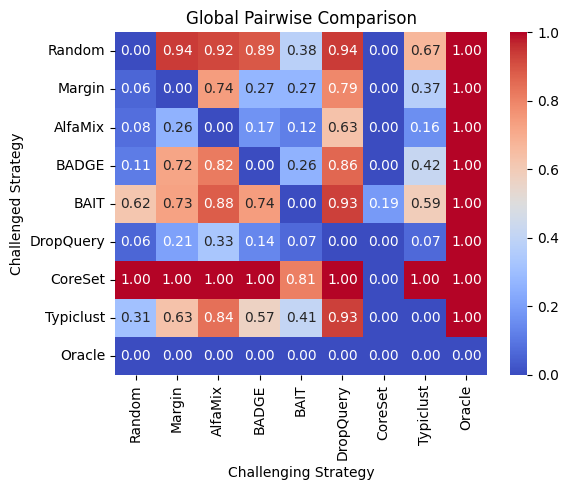

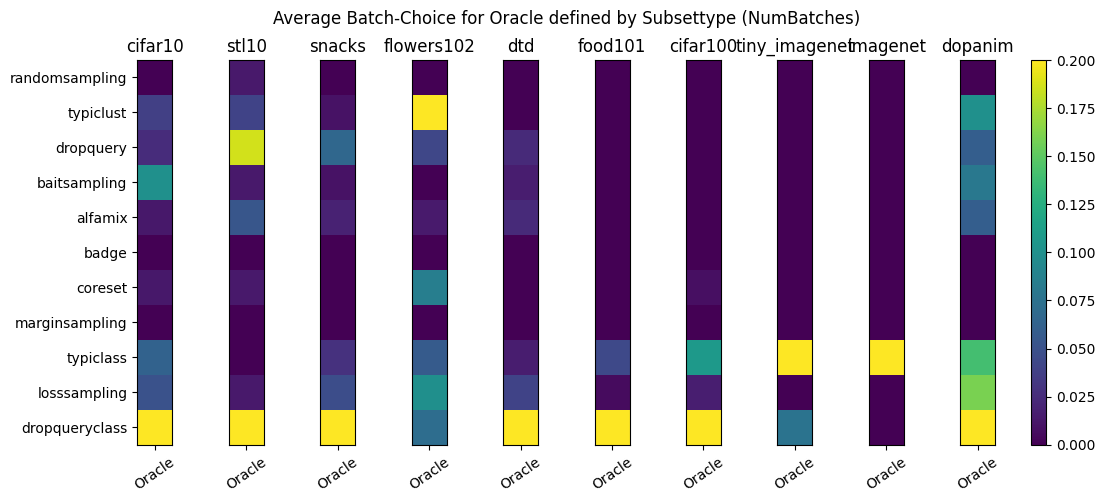

In [94]:
strategies = ['random', 'margin', 'alfamix', 'badge', 'bait', 'dropquery', 'coreset', 'typiclust', 'Oracle']
Labels = [query_strategies[strat]['n'] for strat in strategies]
dsets = datasets

final_acc_rel, auc_values_rel = plot_learning_curves(all_acc_curves_strategies_2, strats=strategies, dsets=dsets, datasets=datasets, query_strategies=query_strategies, nrows=2, ncols=5, figsize=(20, 9))

print('##################################### Final Test-Accuracies (Relative to Random) #####################################')
df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

print('##################################### Test-AUCs (Relative to Random) #####################################')
df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

plot_global_pairwise_comparison(all_acc_curves_strategies_2, dsets, strategies, figsize=(6,5), Labels=Labels)

fig_strats = ['Oracle']
fig_labels = ['Oracle']
plot_average_pick_choices(all_pick_choices_2, fig_strats, dsets, sampling_strategies, fig_labels, figsize=(12, 5))

# Additional Ablations

## Sequential Selection Strategy Reduction

These experiments aim to investigate how our model behaves if we sequentially reduce its pick choices by the least picked Choice

In [ ]:
cmap = 'viridis'
fig_strats = ['lazy+vary oracle(110)']
fig_dsets = ['cifar10', 'dtd']
sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling', 'alfamix', 'badge', 'coreset', 'marginsampling', 'typiclass', 'losssampling', 'dropqueryclass']
n_plots = len(fig_dsets) * len(fig_strats)

fig, ax = plt.subplots(nrows=1, ncols=n_plots + 1, figsize=(4, 5), width_ratios=[1 for _ in range(n_plots)]+ [.2])
fig.suptitle("Average Batch-Choice for Oracle defined by Subsettype (NumBatches)")

for a, dset in enumerate(fig_dsets):
    query_size = datasets[dset]['qs']
    for b, strat in enumerate(fig_strats):
        n_queries = 20 if '10' in strat else (10 if '20' in strat else 5)
        
        j = a * len(fig_strats) + b
        vmin, vmax = 1, 0
        
        image = []
        for sampl_strat in sampling_strategies:
            img = []
            for seed in range(10):
                im = []
                if seed < len(all_pick_choices[dset][strat]):
                    for i in range(n_queries):
                        if sampl_strat in all_pick_choices[dset][strat][seed] and len(all_pick_choices[dset][strat][seed][sampl_strat])>0:
                            if i == 0:
                                im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                            else:
                                im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                        else:
                            im.append(0)
                    img.append(im)
            image.append(img)
        image = np.array(image)
        img = np.mean(image, axis=1)
        img_avg = np.mean(img, axis=-1, keepdims=True)

        vmin, vmax = min(vmin, min(img_avg)), max(vmax, max(img_avg))

        c1 = ax[j].imshow(img_avg)
        ax[j].set_xticks(ticks=[0], labels=[("Vary" if "vary" in strat else "Static") + " ("+strat.split('(')[1][:-1]+")"])
        if j == 0:
            ax[j].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
        else:
            ax[j].set_yticks([])
        ax[j].set_title(dset)

        j += 1

fig.colorbar(c1, cax=ax[-1])
plt.show()

### Removing BADGE from selection strategies

In [ ]:
experiment_name = 'experiment_9_1'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10)) # n_dsets * n_seeds

for run in runs_strategies:
    key = 'Oracle (-0)'
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

    if str(len(accs)-1) == run.data.params['al.num_acq']:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

In [ ]:
cmap = 'viridis'
fig_strats = ['Oracle (-0)']
fig_dsets = ['cifar10', 'dtd']
sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling', 'alfamix', 'coreset', 'marginsampling', 'badge', 'typiclass', 'losssampling', 'dropqueryclass']
n_plots = len(fig_dsets) * len(fig_strats)

fig, ax = plt.subplots(nrows=1, ncols=n_plots + 1, figsize=(4, 5), width_ratios=[1 for _ in range(n_plots)]+ [.2])
fig.suptitle("Average Batch-Choice for Oracle")

for a, dset in enumerate(fig_dsets):
    query_size = datasets[dset]['qs']
    for b, strat in enumerate(fig_strats):
        n_queries = 20
        
        j = a * len(fig_strats) + b
        vmin, vmax = 1, 0
        
        image = []
        for sampl_strat in sampling_strategies:
            img = []
            for seed in range(10):
                im = []
                if seed < len(all_pick_choices[dset][strat]):
                    for i in range(n_queries):
                        if sampl_strat in all_pick_choices[dset][strat][seed] and len(all_pick_choices[dset][strat][seed][sampl_strat]) > 0:
                            if i == 0:
                                im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                            else:
                                im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                        else:
                            im.append(0)
                    img.append(im)
            image.append(img)
        image = np.array(image)
        img = np.mean(image, axis=1)
        img_avg = np.mean(img, axis=-1, keepdims=True)

        vmin, vmax = min(vmin, min(img_avg)), max(vmax, max(img_avg))

        c1 = ax[j].imshow(img_avg)
        ax[j].set_xticks(ticks=[0], labels=['10 Seeds' if 'vary' in strat else '1 Seed'])
        if j == 0:
            ax[j].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
        else:
            ax[j].set_yticks([])
        ax[j].set_title(dset)

        j += 1

fig.colorbar(c1, cax=ax[-1])
plt.show()

In [ ]:
experiment_name = 'experiment_9_2'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10)) # n_dsets * n_seeds

for run in runs_strategies:
    key = 'Oracle (-1)'
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

    if str(len(accs)-1) == run.data.params['al.num_acq']:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

In [ ]:
cmap = 'viridis'
fig_strats = ['Oracle (-1)']
fig_dsets = ['cifar10', 'dtd']
sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling', 'alfamix', 'coreset', 'badge', 'typiclass', 'losssampling', 'dropqueryclass']
n_plots = len(fig_dsets) * len(fig_strats)

fig, ax = plt.subplots(nrows=1, ncols=n_plots + 1, figsize=(4, 5), width_ratios=[1 for _ in range(n_plots)]+ [.2])
fig.suptitle("Average Batch-Choice for Oracle")

for a, dset in enumerate(fig_dsets):
    query_size = datasets[dset]['qs']
    for b, strat in enumerate(fig_strats):
        n_queries = 20
        
        j = a * len(fig_strats) + b
        vmin, vmax = 1, 0
        
        image = []
        for sampl_strat in sampling_strategies:
            img = []
            for seed in range(10):
                im = []
                if seed < len(all_pick_choices[dset][strat]):
                    for i in range(n_queries):
                        if sampl_strat in all_pick_choices[dset][strat][seed] and len(all_pick_choices[dset][strat][seed][sampl_strat]) > 0:
                            if i == 0:
                                im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                            else:
                                im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                        else:
                            im.append(0)
                    img.append(im)
            image.append(img)
        image = np.array(image)
        img = np.mean(image, axis=1)
        img_avg = np.mean(img, axis=-1, keepdims=True)

        vmin, vmax = min(vmin, min(img_avg)), max(vmax, max(img_avg))

        # TODO: Show numbers
        c1 = ax[j].imshow(img_avg)
        ax[j].set_xticks(ticks=[0], labels=['10 Seeds' if 'vary' in strat else '1 Seed'])
        if j == 0:
            ax[j].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
        else:
            ax[j].set_yticks([])
        ax[j].set_title(dset)

        j += 1

fig.colorbar(c1, cax=ax[-1])
plt.show()

In [ ]:
experiment_name = 'experiment_9_3'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10)) # n_dsets * n_seeds

for run in runs_strategies:
    key = 'Oracle (-2)'
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

    if str(len(accs)-1) == run.data.params['al.num_acq']:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

In [ ]:
cmap = 'viridis'
fig_strats = ['Oracle (-2)']
fig_dsets = ['cifar10', 'dtd']
sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling', 'coreset', 'badge', 'typiclass', 'losssampling', 'dropqueryclass']
n_plots = len(fig_dsets) * len(fig_strats)

fig, ax = plt.subplots(nrows=1, ncols=n_plots + 1, figsize=(4, 5), width_ratios=[1 for _ in range(n_plots)]+ [.2])
fig.suptitle("Average Batch-Choice for Oracle")

for a, dset in enumerate(fig_dsets):
    query_size = datasets[dset]['qs']
    for b, strat in enumerate(fig_strats):
        n_queries = 20
        
        j = a * len(fig_strats) + b
        vmin, vmax = 1, 0
        
        image = []
        for sampl_strat in sampling_strategies:
            img = []
            for seed in range(10):
                im = []
                if seed < len(all_pick_choices[dset][strat]):
                    for i in range(n_queries):
                        if sampl_strat in all_pick_choices[dset][strat][seed] and len(all_pick_choices[dset][strat][seed][sampl_strat]) > 0:
                            if i == 0:
                                im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                            else:
                                im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                        else:
                            im.append(0)
                    img.append(im)
            image.append(img)
        image = np.array(image)
        img = np.mean(image, axis=1)
        img_avg = np.mean(img, axis=-1, keepdims=True)

        vmin, vmax = min(vmin, min(img_avg)), max(vmax, max(img_avg))

        # TODO: Show numbers
        c1 = ax[j].imshow(img_avg)
        ax[j].set_xticks(ticks=[0], labels=['10 Seeds' if 'vary' in strat else '1 Seed'])
        if j == 0:
            ax[j].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
        else:
            ax[j].set_yticks([])
        ax[j].set_title(dset)

        j += 1

fig.colorbar(c1, cax=ax[-1])
plt.show()

In [ ]:
experiment_name = 'experiment_9_4'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10)) # n_dsets * n_seeds

for run in runs_strategies:
    key = 'Oracle (-3)'
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

    if str(len(accs)-1) == run.data.params['al.num_acq']:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
        if dataset not in all_pick_choices:
            all_pick_choices[dataset] = defaultdict(list)
        all_pick_choices[dataset][key].append(pick_choices)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

In [ ]:
cmap = 'viridis'
fig_strats = ['Oracle (-3)']
fig_dsets = ['cifar10', 'dtd']
sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling', 'coreset', 'typiclass', 'losssampling', 'dropqueryclass']
n_plots = len(fig_dsets) * len(fig_strats)

fig, ax = plt.subplots(nrows=1, ncols=n_plots + 1, figsize=(4, 5), width_ratios=[1 for _ in range(n_plots)]+ [.2])
fig.suptitle("Average Batch-Choice for Oracle")

for a, dset in enumerate(fig_dsets):
    query_size = datasets[dset]['qs']
    for b, strat in enumerate(fig_strats):
        n_queries = 20
        
        j = a * len(fig_strats) + b
        vmin, vmax = 1, 0
        
        image = []
        for sampl_strat in sampling_strategies:
            img = []
            for seed in range(10):
                im = []
                if seed < len(all_pick_choices[dset][strat]):
                    for i in range(n_queries):
                        if sampl_strat in all_pick_choices[dset][strat][seed] and len(all_pick_choices[dset][strat][seed][sampl_strat]) > 0:
                            if i == 0:
                                im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                            else:
                                im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                        else:
                            im.append(0)
                    img.append(im)
            image.append(img)
        image = np.array(image)
        img = np.mean(image, axis=1)
        img_avg = np.mean(img, axis=-1, keepdims=True)

        vmin, vmax = min(vmin, min(img_avg)), max(vmax, max(img_avg))

        # TODO: Show numbers
        c1 = ax[j].imshow(img_avg)
        ax[j].set_xticks(ticks=[0], labels=['10 Seeds' if 'vary' in strat else '1 Seed'])
        if j == 0:
            ax[j].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
        else:
            ax[j].set_yticks([])
        ax[j].set_title(dset)

        j += 1

fig.colorbar(c1, cax=ax[-1])
plt.show()

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4), tight_layout=True)
auc_values_rel = {}
final_acc_rel = {}
strategies = ['Oracle (-0)', 'Oracle (-1)', 'Oracle (-2)', 'Oracle (-3)']

for i, dset in enumerate(['cifar10', 'dtd']):
    auc_values_rel[dset] = {}
    final_acc_rel[dset] = {}

    rand_accs = all_acc_curves_strategies[dset]['Oracle'] 
    avg_rand_accs = np.mean(rand_accs, axis=0)
    rand_auc = np.mean(rand_accs, axis=1)
    rand_final_accs = [ac[-1]*100 for ac in rand_accs]
    rand_auc_mean, rand_auc_std = np.mean(rand_auc), np.std(rand_auc)
    rand_acc_mean, rand_acc_std = np.mean(rand_final_accs), np.std(rand_final_accs)
    auc_values_rel[dset]['Oracle'] = str(rand_auc_mean.round(3)) + '+/-' + str(rand_auc_std.round(3))
    final_acc_rel[dset]['Oracle'] = str(rand_acc_mean.round(2)) + '+/-' + str(rand_acc_std.round(2))

    plt.axes(ax[i])
    n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(21)]
    for qs in all_acc_curves_strategies[dset]:
        if qs in strategies:
            accs = all_acc_curves_strategies[dset][qs]
            avg_accs = np.mean(accs, axis=0)
            final_accs = [ac[-1]*100 for ac in accs]
            aucs = np.mean(accs, axis=1)
            aucs_mean, aucs_std  = np.mean(aucs), np.std(aucs)
            final_acc_mean, final_acc_std = np.mean(final_accs), np.std(final_accs)

            if qs != 'Oracle':
                auc_values_rel[dset][qs] = str((aucs_mean - rand_auc_mean).round(3)) + '+/-' + str(aucs_std.round(3))
                final_acc_rel[dset][qs] = str((final_acc_mean - rand_acc_mean).round(2)) + '+/-' + str(final_acc_std.round(2))

            plt.plot(n_labeled_samples, avg_accs - avg_rand_accs, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle=query_strategies[qs]['ls'])
    plt.xlabel('Labeled Samples')
    plt.ylabel('Relative Test Accuracy \n Improvement (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])
handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.125, .5], handles=handles, labels=labels)
plt.show()

df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == "Oracle"], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == "Oracle"], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

plot_global_pairwise_comparison(all_acc_curves_strategies, all_acc_curves_strategies.keys(), strategies)
plot_global_comparison(all_acc_curves_strategies, all_acc_curves_strategies.keys(), strategies)